In [1]:
import pandas as pd
import numpy as np
from contextlib import contextmanager
from datetime import datetime
from pathlib import Path
from typing import Optional
import matplotlib.pyplot as plt
import polars as pl
import psutil
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# 1. Coinmetrics

In [2]:
# read data
df = pd.read_csv("../data/Coin Metrics/coinmetrics_btc.csv")
df["time"] = pd.to_datetime(df["time"])
df.head()

,time,AdrActCnt,AdrBalCnt,AssetCompletionTime,AssetEODCompletionTime,BlkCnt,CapMVRVCur,CapMrktCurUSD,CapMrktEstUSD,FeeTotNtv,...,ReferenceRateETH,ReferenceRateEUR,ReferenceRateUSD,SplyCur,SplyExNtv,SplyExUSD,SplyExpFut10yr,TxCnt,TxTfrCnt,volume_reported_spot_usd_1d
0,2009-01-03,0.0,0.0,1.614335e+09,1.614335e+09,0.0,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0,NaN
1,2009-01-04,0.0,0.0,1.614335e+09,1.614335e+09,0.0,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0,NaN
2,2009-01-05,0.0,0.0,1.614335e+09,1.614335e+09,0.0,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0,NaN
3,2009-01-06,0.0,0.0,1.614335e+09,1.614335e+09,0.0,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0,NaN
4,2009-01-07,0.0,0.0,1.614335e+09,1.614335e+09,0.0,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0,NaN


In [3]:
# test the commit
start = "2018-01-01"
end = "2025-12-31"
df = df[(df["time"] >= start) & (df["time"] <= end)].copy()
# sort and set the index
df = df.sort_values("time").set_index("time")

In [4]:
# check missing date
all_days = pd.date_range(start, end, freq="D")
missing_days = all_days.difference(df.index)
len(missing_days)

0

In [5]:
# missing rate
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
print("missing rate Top 20（%）：")
print(missing_pct.head(20))

key_cols = [
    "PriceUSD", "CapMrktCurUSD", "HashRate", "TxCnt",
    "CapMVRVCur", "SplyCur", "FeeTotNtv",
    "FlowInExUSD", "FlowOutExUSD",
    "volume_reported_spot_usd_1d"
]
key_cols = [c for c in key_cols if c in df.columns]

print("\nkey row describe：")
print(df[key_cols].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T)

missing rate Top 20（%）：
ReferenceRate             100.000000
ReferenceRateEUR          100.000000
ReferenceRateETH          100.000000
ReferenceRateUSD          100.000000
CapMrktEstUSD              18.377823
AdrBalCnt                   0.000000
AdrActCnt                   0.000000
CapMrktCurUSD               0.000000
FeeTotNtv                   0.000000
FlowInExNtv                 0.000000
FlowInExUSD                 0.000000
AssetEODCompletionTime      0.000000
BlkCnt                      0.000000
CapMVRVCur                  0.000000
AssetCompletionTime         0.000000
IssTotNtv                   0.000000
HashRate                    0.000000
FlowOutExUSD                0.000000
FlowOutExNtv                0.000000
ROI1yr                      0.000000
dtype: float64

key row describe：
                              count          mean           std           min  \
PriceUSD                     2922.0  3.726383e+04  3.222417e+04  3.185074e+03   
CapMrktCurUSD                2922.0  7.2

In [6]:
# Basic integrity checks
print("Rows:", len(df))
print("Time range:", df.index.min(), "→", df.index.max())

print(df.index.is_monotonic_increasing)
print(df.index.is_unique)

print("\nMissing values (top 10 columns):")
print(df.isna().sum().sort_values(ascending=False).head(10))

Rows: 2922
Time range: 2018-01-01 00:00:00 → 2025-12-31 00:00:00
True
True

Missing values (top 10 columns):
ReferenceRate       2922
ReferenceRateEUR    2922
ReferenceRateETH    2922
ReferenceRateUSD    2922
CapMrktEstUSD        537
AdrBalCnt              0
AdrActCnt              0
CapMrktCurUSD          0
FeeTotNtv              0
FlowInExNtv            0
dtype: int64


In [7]:
# 6) create metrics

px = df["PriceUSD"]

df["ret_1d"] = px.pct_change()
df["logret_1d"] = np.log(px).diff()

# annualized vol
df["vol_30d"] = df["logret_1d"].rolling(30).std() * np.sqrt(365)

# 200 DMA
df["ma_200"] = px.rolling(200).mean()
df["price_vs_ma200"] = px / df["ma_200"] - 1

# Drawdown
rolling_max = px.cummax()
df["drawdown"] = px / rolling_max - 1


In [8]:
df.columns

Index(['AdrActCnt', 'AdrBalCnt', 'AssetCompletionTime',
       'AssetEODCompletionTime', 'BlkCnt', 'CapMVRVCur', 'CapMrktCurUSD',
       'CapMrktEstUSD', 'FeeTotNtv', 'FlowInExNtv', 'FlowInExUSD',
       'FlowOutExNtv', 'FlowOutExUSD', 'HashRate', 'IssTotNtv', 'IssTotUSD',
       'PriceBTC', 'PriceUSD', 'ROI1yr', 'ROI30d', 'ReferenceRate',
       'ReferenceRateETH', 'ReferenceRateEUR', 'ReferenceRateUSD', 'SplyCur',
       'SplyExNtv', 'SplyExUSD', 'SplyExpFut10yr', 'TxCnt', 'TxTfrCnt',
       'volume_reported_spot_usd_1d', 'ret_1d', 'logret_1d', 'vol_30d',
       'ma_200', 'price_vs_ma200', 'drawdown'],
      dtype='object')

In [9]:
df.head()

,AdrActCnt,AdrBalCnt,AssetCompletionTime,AssetEODCompletionTime,BlkCnt,CapMVRVCur,CapMrktCurUSD,CapMrktEstUSD,FeeTotNtv,FlowInExNtv,...,SplyExpFut10yr,TxCnt,TxTfrCnt,volume_reported_spot_usd_1d,ret_1d,logret_1d,vol_30d,ma_200,price_vs_ma200,drawdown
time,,,,,,,,,,,,,,,,,,,,,
2018-01-01,972783.0,26829117.0,1.614337e+09,1.614337e+09,156.0,2.694235,2.258877e+11,NaN,477.225170,36000.622080,...,2.027413e+07,241625.0,677625.0,4.860752e+09,NaN,NaN,NaN,NaN,NaN,0.0
2018-01-02,1142721.0,26909375.0,1.614337e+09,1.614337e+09,171.0,2.925443,2.475552e+11,NaN,649.878138,65831.310897,...,2.027467e+07,343664.0,960051.0,8.485368e+09,0.095782,0.091468,NaN,NaN,NaN,0.0
2018-01-03,1130917.0,27133378.0,1.614337e+09,1.614337e+09,157.0,2.960267,2.518793e+11,NaN,750.020447,56969.474964,...,2.027516e+07,396942.0,1049679.0,8.041486e+09,0.017348,0.017200,NaN,NaN,NaN,0.0
2018-01-04,1253986.0,27415056.0,1.614337e+09,1.614337e+09,168.0,2.944022,2.529181e+11,NaN,777.017867,77816.063305,...,2.027568e+07,424762.0,1191394.0,1.138178e+10,0.003998,0.003990,NaN,NaN,NaN,0.0
2018-01-05,1069525.0,27645350.0,1.614337e+09,1.614337e+09,143.0,3.261964,2.852872e+11,NaN,704.313737,72765.218396,...,2.027613e+07,339441.0,1002989.0,1.288165e+10,0.127863,0.120324,NaN,NaN,NaN,0.0


# 2. Coinmetrics EDA

In [10]:
metrics = ["PriceUSD", "CapMrktCurUSD", "HashRate"]
df[metrics].describe()

,PriceUSD,CapMrktCurUSD,HashRate
count,2922.000000,2.922000e+03,2.922000e+03
mean,37263.830507,7.219058e+11,3.164267e+08
std,32224.168884,6.439132e+11,3.023951e+08
min,3185.074044,5.549965e+10,1.372762e+07
25%,9447.177429,1.706965e+11,9.550205e+07
50%,27320.277455,5.303925e+11,1.780076e+08
75%,57402.905528,1.085182e+12,5.065075e+08
max,124824.453667,2.487865e+12,1.305500e+09


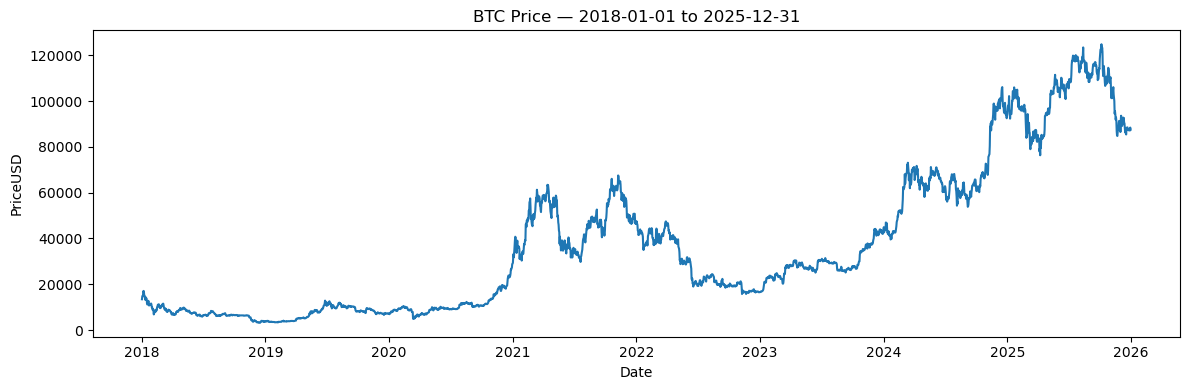

In [11]:
# Price Trend
plt.figure(figsize=(12, 4))
plt.plot(df.index, df["PriceUSD"])
plt.title("BTC Price — 2018-01-01 to 2025-12-31")
plt.xlabel("Date")
plt.ylabel("PriceUSD")
plt.tight_layout()
plt.show()

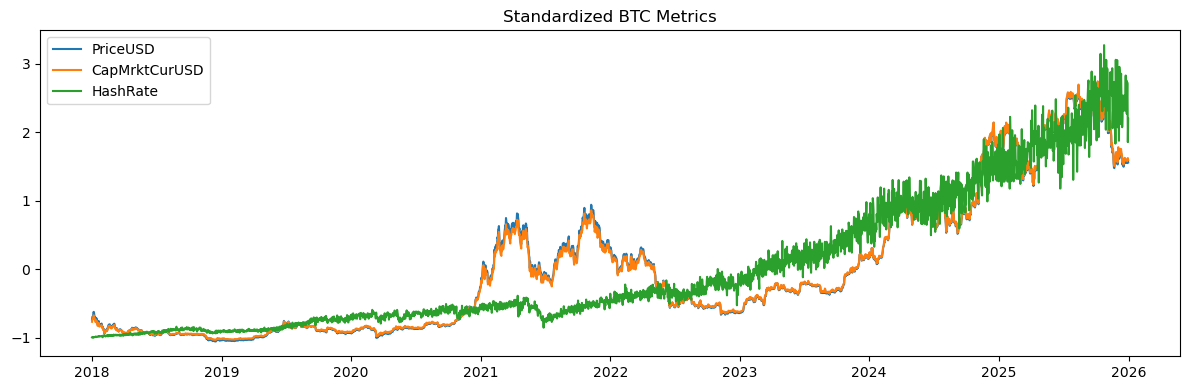

In [12]:
cols = ["PriceUSD", "CapMrktCurUSD", "HashRate"]
scaled = StandardScaler().fit_transform(df[cols])

plt.figure(figsize=(12,4))
plt.plot(df.index, scaled)
plt.legend(cols)
plt.title("Standardized BTC Metrics")
plt.tight_layout()
plt.savefig("plots/Standardized BTC Metrics.png", dpi=300)
plt.show()

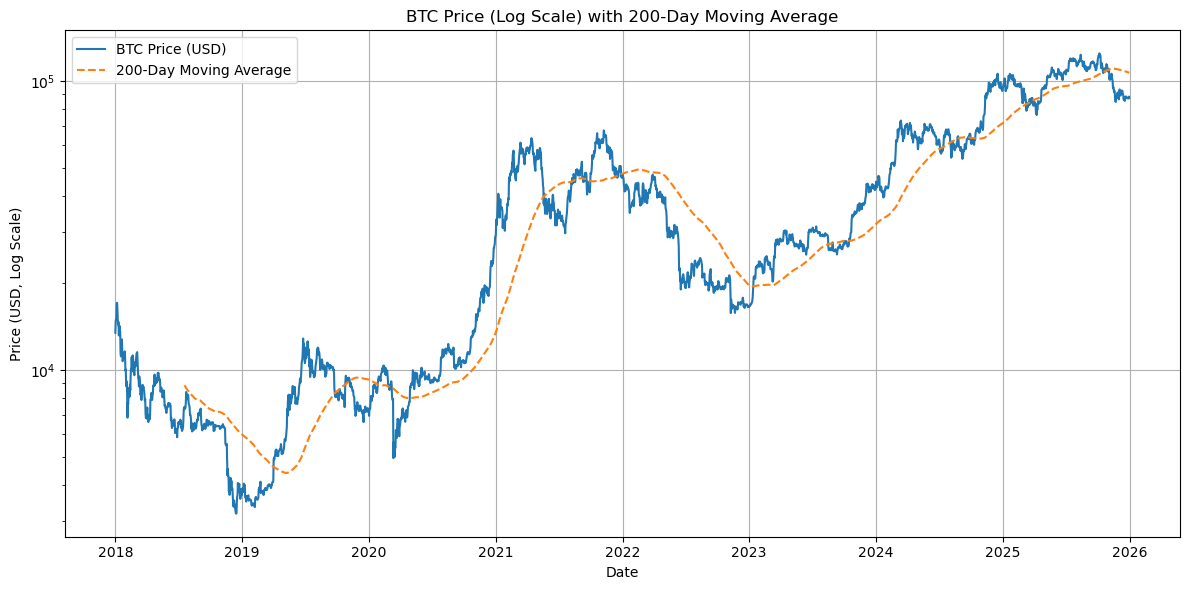

In [13]:
# BTC Price (Log Scale) with 200-Day Moving Average
plt.figure(figsize=(12, 6))
plt.plot(df.index, df["PriceUSD"], label="BTC Price (USD)")
plt.plot(df.index, df["ma_200"], label="200-Day Moving Average", linestyle="--")

plt.yscale("log")

plt.title("BTC Price (Log Scale) with 200-Day Moving Average")
plt.xlabel("Date")
plt.ylabel("Price (USD, Log Scale)")

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

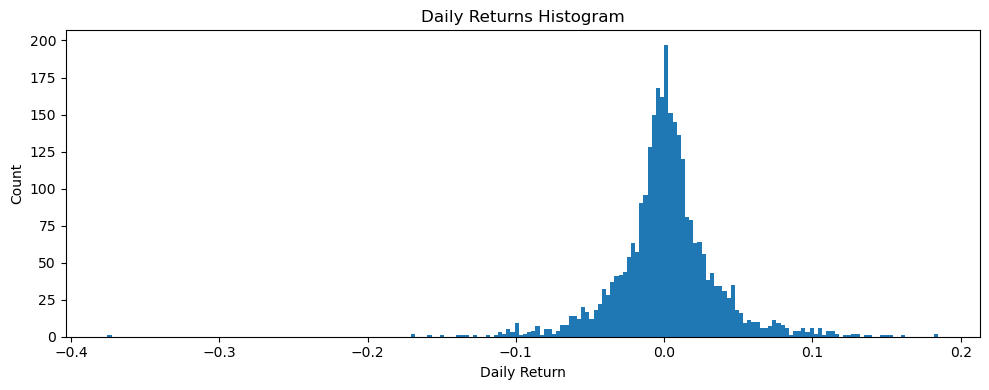

In [14]:
# Daily Profit Distribution
rets = df["ret_1d"].dropna()
plt.figure(figsize=(10, 4))
plt.hist(rets, bins=200)
plt.title("Daily Returns Histogram")
plt.xlabel("Daily Return")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [15]:
print("\nWorst 10 Days (ret_1d):")
print(rets.nsmallest(10))

print("\nBest 10 Days (ret_1d):")
print(rets.nlargest(10))


Worst 10 Days (ret_1d):
time
2020-03-12   -0.375350
2018-02-05   -0.169805
2022-06-13   -0.168244
2018-01-16   -0.158969
2022-11-09   -0.149165
2018-11-19   -0.137376
2019-06-27   -0.136329
2019-07-16   -0.133186
2021-01-21   -0.126495
2021-05-19   -0.120292
Name: ret_1d, dtype: float64

Best 10 Days (ret_1d):
time
2019-04-02    0.184926
2021-02-08    0.182522
2019-10-25    0.161286
2019-05-11    0.152202
2020-03-19    0.150406
2022-02-28    0.146409
2018-04-12    0.138168
2020-03-13    0.134772
2018-02-06    0.129804
2019-05-19    0.129398
Name: ret_1d, dtype: float64


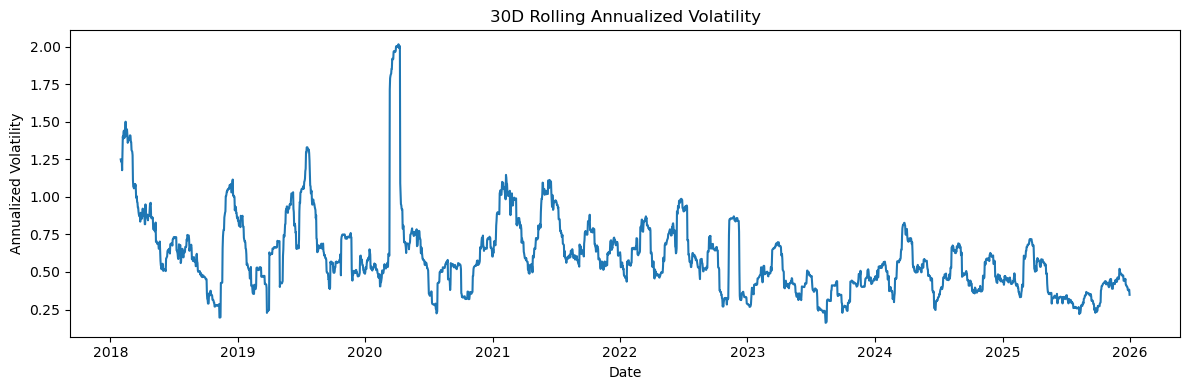

In [16]:
# 30D Rolling Annualized Volatility
plt.figure(figsize=(12, 4))
plt.plot(df.index, df["vol_30d"])
plt.title("30D Rolling Annualized Volatility")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.tight_layout()
plt.show()

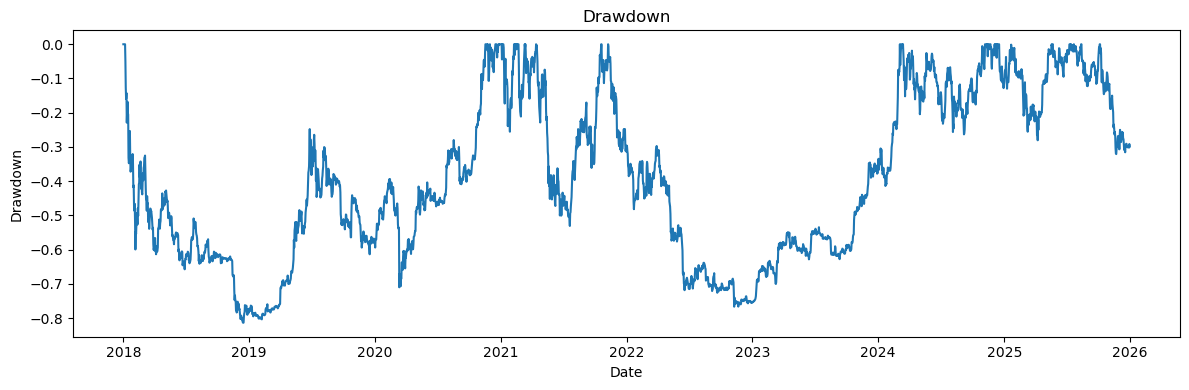

In [17]:
# Drawdown Plot
plt.figure(figsize=(12, 4))
plt.plot(df.index, df["drawdown"])
plt.title("Drawdown")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.tight_layout()
plt.show()

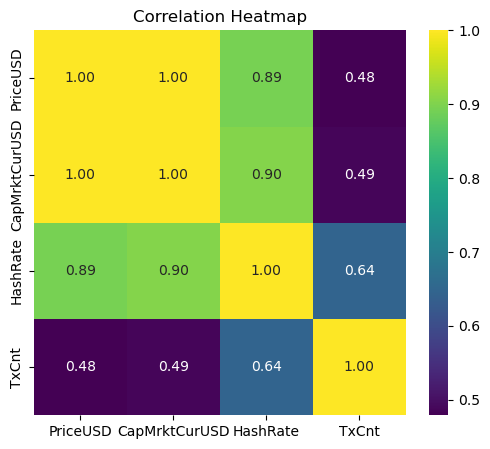

In [18]:
#Correlation Heatmap
correlation_cols = ["PriceUSD", "CapMrktCurUSD", "HashRate", "TxCnt"]
corr_df = df[correlation_cols].apply(pd.to_numeric, errors="coerce")

# corr
corr = corr_df.corr()

# heatmap
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="viridis", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

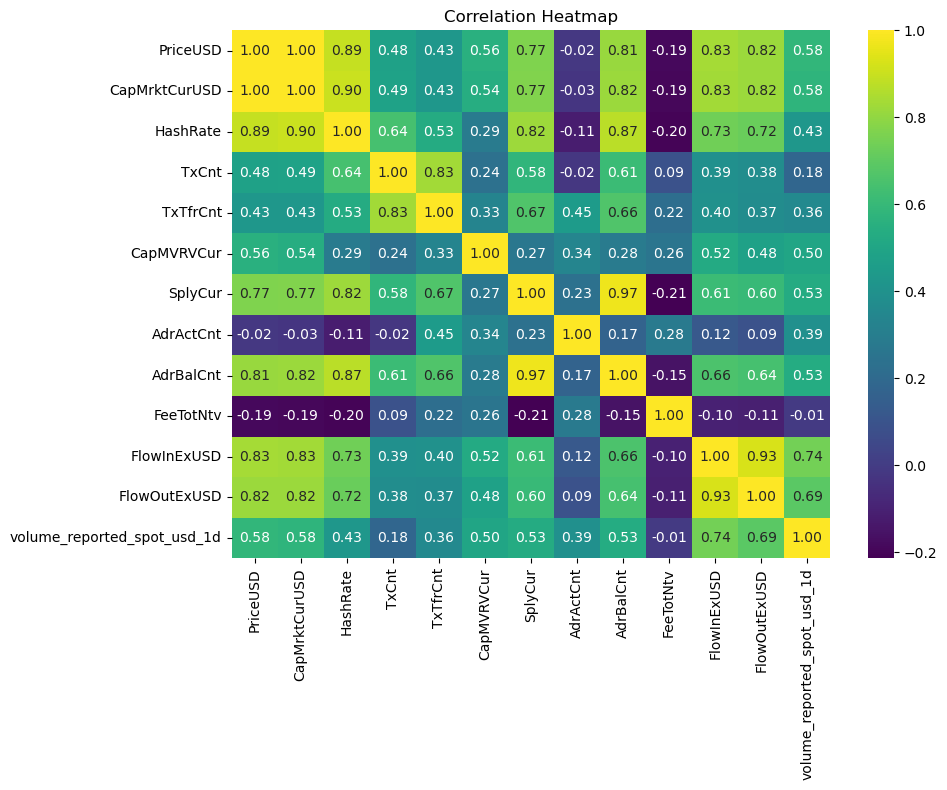

In [19]:
corr_cols = [
    "PriceUSD", "CapMrktCurUSD", "HashRate", "TxCnt", "TxTfrCnt",
    "CapMVRVCur", "SplyCur", "AdrActCnt", "AdrBalCnt",
    "FeeTotNtv", "FlowInExUSD", "FlowOutExUSD",
    "volume_reported_spot_usd_1d"
]
corr_cols = [c for c in corr_cols if c in df.columns]

corr = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="viridis", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("plots/correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

In [20]:
# Build accumulation common metrics
# net inflow >0 means net outflow ，<0 means net inflow
df["net_flow_usd"] = df["FlowOutExUSD"] - df["FlowInExUSD"]

# PnL in next 30 days
h = 30
df["fwd_ret_30d"] = df["PriceUSD"].shift(-h) / df["PriceUSD"] - 1

# Forward vol in 30D log return
logret = np.log(df["PriceUSD"]).diff()
df["fwd_vol_30d"] = logret.shift(-1).rolling(h).std() * np.sqrt(365)

# Max Drawdown in next 30D
# Make the lowest price in the forward window, then convert to max drawdown
future_min_price = df["PriceUSD"].shift(-1).rolling(h).min()
df["fwd_min_dd_30d"] = future_min_price / df["PriceUSD"] - 1 

# Remove missing data in the last 30D
eda = df.dropna(subset=["fwd_ret_30d", "fwd_vol_30d", "fwd_min_dd_30d"]).copy()



===  MVRV（CapMVRVCur）5 Buckets Grouping Result ===
  mvrv_q5    n  avg_fwd_ret_30d  med_fwd_ret_30d  avg_fwd_vol_30d  \
0       1  573         0.075359         0.054146         0.670342   
1       2  572         0.020615         0.000193         0.527412   
2       3  573         0.030614         0.012754         0.654079   
3       4  572         0.045156         0.012082         0.562571   
4       5  573         0.043455        -0.008083         0.601273   

   prob_dd_lt_20pct  prob_dd_lt_30pct  
0          0.136126          0.001745  
1          0.092657          0.008741  
2          0.211169          0.050611  
3          0.164336          0.050699  
4          0.392670          0.184991  


C:\Users\quant\AppData\Local\Temp\ipykernel_8316\2938279399.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mvrv_table = eda.groupby("mvrv_q5").agg(


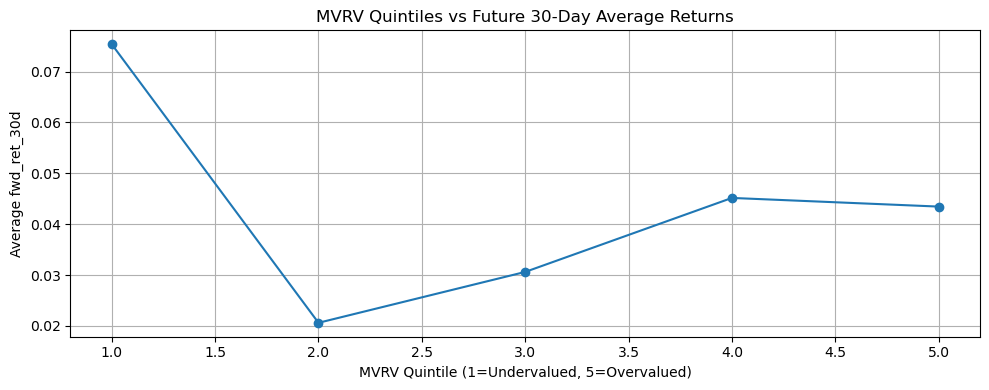

In [21]:
#One dimensional bin analysis 
#Group into 5 binnings by MVRV
eda["mvrv_q5"] = pd.qcut(eda["CapMVRVCur"], 5, labels=[1,2,3,4,5])
mvrv_table = eda.groupby("mvrv_q5").agg(
    n=("PriceUSD", "size"),
    avg_fwd_ret_30d=("fwd_ret_30d", "mean"),
    med_fwd_ret_30d=("fwd_ret_30d", "median"),
    avg_fwd_vol_30d=("fwd_vol_30d", "mean"),
    prob_dd_lt_20pct=("fwd_min_dd_30d", lambda x: (x < -0.20).mean()),
    prob_dd_lt_30pct=("fwd_min_dd_30d", lambda x: (x < -0.30).mean()),
).reset_index()

print("\n===  MVRV（CapMVRVCur）5 Buckets Grouping Result ===")
print(mvrv_table)

plt.figure(figsize=(10,4))
plt.plot(mvrv_table["mvrv_q5"], mvrv_table["avg_fwd_ret_30d"], marker="o")
plt.title("MVRV Quintiles vs Future 30-Day Average Returns")
plt.xlabel("MVRV Quintile (1=Undervalued, 5=Overvalued)")
plt.ylabel("Average fwd_ret_30d")
plt.grid(True)
plt.tight_layout()
plt.show()

C:\Users\quant\AppData\Local\Temp\ipykernel_8316\1853302691.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  netflow_table = eda.groupby("netflow_q5").agg(



=== Net Flow (net_flow_usd) Quintile Binning Results ===
  netflow_q5    n  avg_fwd_ret_30d  med_fwd_ret_30d  avg_fwd_vol_30d  \
0          1  573         0.019433        -0.014197         0.624681   
1          2  572         0.044643         0.022561         0.616223   
2          3  573         0.052355         0.025048         0.620103   
3          4  572         0.061835         0.027716         0.610376   
4          5  573         0.037003         0.007718         0.544532   

   prob_dd_lt_20pct  prob_dd_lt_30pct  
0          0.226876          0.099476  
1          0.187063          0.052448  
2          0.202443          0.043630  
3          0.201049          0.043706  
4          0.179756          0.057592  


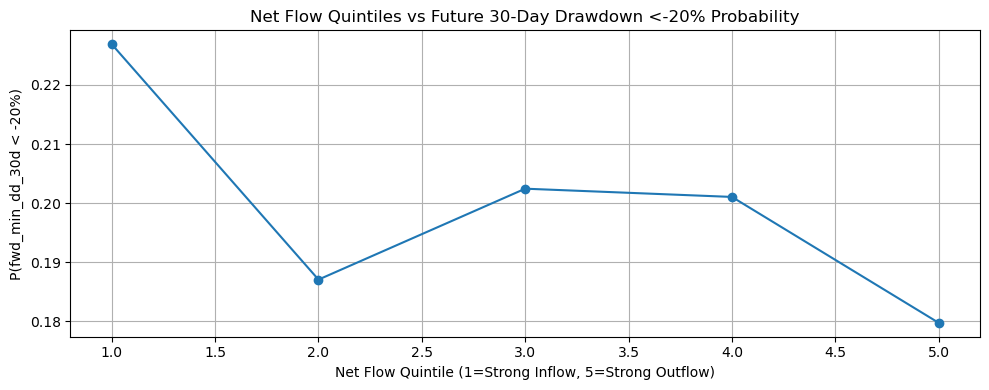

In [22]:
# Based on net_flow_usd group into 5
# showcasing 30D 20% drawdown probability
eda["netflow_q5"] = pd.qcut(eda["net_flow_usd"], 5, labels=[1,2,3,4,5])
netflow_table = eda.groupby("netflow_q5").agg(
    n=("PriceUSD", "size"),
    avg_fwd_ret_30d=("fwd_ret_30d", "mean"),
    med_fwd_ret_30d=("fwd_ret_30d", "median"),
    avg_fwd_vol_30d=("fwd_vol_30d", "mean"),
    prob_dd_lt_20pct=("fwd_min_dd_30d", lambda x: (x < -0.20).mean()),
    prob_dd_lt_30pct=("fwd_min_dd_30d", lambda x: (x < -0.30).mean()),
).reset_index()

print("\n=== Net Flow (net_flow_usd) Quintile Binning Results ===")
print(netflow_table)

plt.figure(figsize=(10,4))
plt.plot(netflow_table["netflow_q5"], netflow_table["prob_dd_lt_20pct"], marker="o")
plt.title("Net Flow Quintiles vs Future 30-Day Drawdown <-20% Probability")
plt.xlabel("Net Flow Quintile (1=Strong Inflow, 5=Strong Outflow)")
plt.ylabel("P(fwd_min_dd_30d < -20%)")
plt.grid(True)
plt.tight_layout()
plt.show()


=== （AdrActCnt）Quintile Binning Results ===
  adract_q5    n  avg_fwd_ret_30d  med_fwd_ret_30d  avg_fwd_vol_30d  \
0         1  573         0.017177        -0.002325         0.630627   
1         2  572         0.021092         0.001985         0.569494   
2         3  573         0.059636         0.023675         0.613425   
3         4  572         0.042854         0.012553         0.584313   
4         5  573         0.074436         0.038444         0.617930   

   prob_dd_lt_20pct  prob_dd_lt_30pct  
0          0.101222          0.008726  
1          0.125874          0.045455  
2          0.211169          0.057592  
3          0.230769          0.055944  
4          0.328098          0.129145  


C:\Users\quant\AppData\Local\Temp\ipykernel_8316\302040175.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adr_table = eda.groupby("adract_q5").agg(
C:\Users\quant\AppData\Local\Temp\ipykernel_8316\302040175.py:21: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\quant\AppData\Local\Temp\ipykernel_8316\302040175.py:21: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\quant\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\quant\AppData\Roaming\Python\Python313\site-packages\IPytho

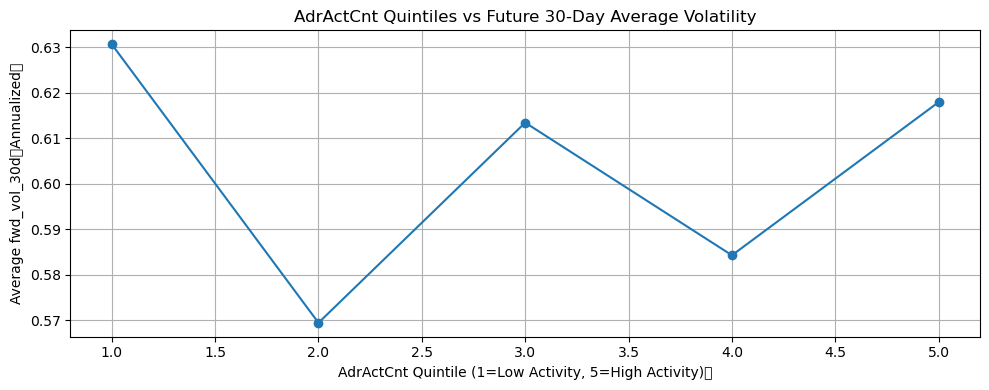

In [23]:
#  AdrActCnt 5 binning
eda["adract_q5"] = pd.qcut(eda["AdrActCnt"], 5, labels=[1,2,3,4,5])
adr_table = eda.groupby("adract_q5").agg(
    n=("PriceUSD", "size"),
    avg_fwd_ret_30d=("fwd_ret_30d", "mean"),
    med_fwd_ret_30d=("fwd_ret_30d", "median"),
    avg_fwd_vol_30d=("fwd_vol_30d", "mean"),
    prob_dd_lt_20pct=("fwd_min_dd_30d", lambda x: (x < -0.20).mean()),
    prob_dd_lt_30pct=("fwd_min_dd_30d", lambda x: (x < -0.30).mean()),
).reset_index()

print("\n=== （AdrActCnt）Quintile Binning Results ===")
print(adr_table)

plt.figure(figsize=(10,4))
plt.plot(adr_table["adract_q5"], adr_table["avg_fwd_vol_30d"], marker="o")
plt.title("AdrActCnt Quintiles vs Future 30-Day Average Volatility")
plt.xlabel("AdrActCnt Quintile (1=Low Activity, 5=High Activity)）")
plt.ylabel("Average fwd_vol_30d（Annualized）")
plt.grid(True)
plt.tight_layout()
plt.show()

C:\Users\quant\AppData\Local\Temp\ipykernel_8316\1169912418.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mvrv_table = eda.groupby("mvrv_q5").agg(
C:\Users\quant\AppData\Local\Temp\ipykernel_8316\1169912418.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  netflow_table = eda.groupby("netflow_q5").agg(
C:\Users\quant\AppData\Local\Temp\ipykernel_8316\1169912418.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

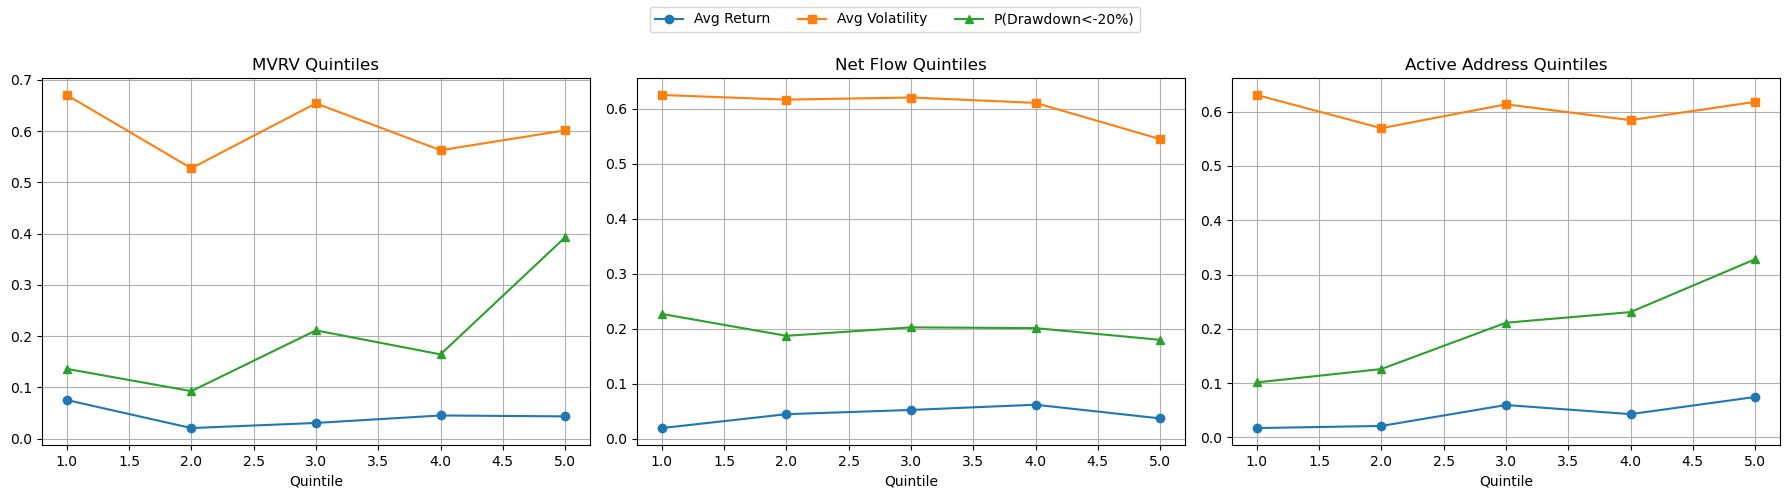

In [24]:
# # Forward-looking performance conditioning analysis
# # 1 Build forward-looking metrics
df["net_flow_usd"] = df["FlowOutExUSD"] - df["FlowInExUSD"]

h = 30
# #
# # Forward 30-day return
df["fwd_ret_30d"] = df["PriceUSD"].shift(-h) / df["PriceUSD"] - 1

# # Forward 30-day volatility (annualized)
# logret = np.log(df["PriceUSD"]).diff()
df["fwd_vol_30d"] = logret.shift(-1).rolling(h).std() * np.sqrt(365)

# Forward 30-day max drawdown
future_min_price = df["PriceUSD"].shift(-1).rolling(h).min()
df["fwd_min_dd_30d"] = future_min_price / df["PriceUSD"] - 1

# Remove NaN
eda = df.dropna(subset=["fwd_ret_30d", 
                        "fwd_vol_30d", 
                        "fwd_min_dd_30d"]).copy()

# 2 Quintile grouping
# MVRV
eda["mvrv_q5"] = pd.qcut(eda["CapMVRVCur"], 5, labels=[1,2,3,4,5])
mvrv_table = eda.groupby("mvrv_q5").agg(
    avg_fwd_ret_30d=("fwd_ret_30d", "mean"),
    avg_fwd_vol_30d=("fwd_vol_30d", "mean"),
    prob_dd_lt_20pct=("fwd_min_dd_30d", lambda x: (x < -0.20).mean()),
).reset_index()

# Net Flow
eda["netflow_q5"] = pd.qcut(eda["net_flow_usd"], 5, labels=[1,2,3,4,5])
netflow_table = eda.groupby("netflow_q5").agg(
    avg_fwd_ret_30d=("fwd_ret_30d", "mean"),
    avg_fwd_vol_30d=("fwd_vol_30d", "mean"),
    prob_dd_lt_20pct=("fwd_min_dd_30d", lambda x: (x < -0.20).mean()),
).reset_index()

# Active Address
eda["adract_q5"] = pd.qcut(eda["AdrActCnt"], 5, labels=[1,2,3,4,5])
adr_table = eda.groupby("adract_q5").agg(
    avg_fwd_ret_30d=("fwd_ret_30d", "mean"),
    avg_fwd_vol_30d=("fwd_vol_30d", "mean"),
    prob_dd_lt_20pct=("fwd_min_dd_30d", lambda x: (x < -0.20).mean()),
).reset_index()

#3 visualization
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# MVRV
axes[0].plot(mvrv_table["mvrv_q5"], 
             mvrv_table["avg_fwd_ret_30d"], marker="o", label="Avg Return")
axes[0].plot(mvrv_table["mvrv_q5"], 
             mvrv_table["avg_fwd_vol_30d"], marker="s", label="Avg Volatility")
axes[0].plot(mvrv_table["mvrv_q5"], 
             mvrv_table["prob_dd_lt_20pct"], marker="^", label="P(Drawdown<-20%)")

axes[0].set_title("MVRV Quintiles")
axes[0].set_xlabel("Quintile")
axes[0].grid(True)

# Net Flow 
axes[1].plot(netflow_table["netflow_q5"], 
             netflow_table["avg_fwd_ret_30d"], marker="o")
axes[1].plot(netflow_table["netflow_q5"], 
             netflow_table["avg_fwd_vol_30d"], marker="s")
axes[1].plot(netflow_table["netflow_q5"], 
             netflow_table["prob_dd_lt_20pct"], marker="^")

axes[1].set_title("Net Flow Quintiles")
axes[1].set_xlabel("Quintile")
axes[1].grid(True)

# Active Address
axes[2].plot(adr_table["adract_q5"], 
             adr_table["avg_fwd_ret_30d"], marker="o")
axes[2].plot(adr_table["adract_q5"], 
             adr_table["avg_fwd_vol_30d"], marker="s")
axes[2].plot(adr_table["adract_q5"], 
             adr_table["prob_dd_lt_20pct"], marker="^")

axes[2].set_title("Active Address Quintiles")
axes[2].set_xlabel("Quintile")
axes[2].grid(True)


# Unified legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3)

plt.tight_layout(rect=[0, 0, 1, 0.92])

plt.savefig("plots/Forward_30D_Factor_Comparison.png",
            dpi=300, bbox_inches="tight")

plt.show()

BTC Recovery Velocity by Drawdown Regime:
                mean       std  count
drawdown                             
Crash       0.008366  0.093300   1861
Correction  0.017872  0.088986    305
Pullback    0.007813  0.076429    409
Stable      0.013464  0.093050    281


C:\Users\quant\AppData\Local\Temp\ipykernel_8316\2678659009.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  recovery_stats = eda.groupby(drawdown_buckets)['recovery_7d'].agg(['mean', 'std', 'count'])
C:\Users\quant\AppData\Local\Temp\ipykernel_8316\2678659009.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=drawdown_buckets, y=eda['recovery_7d'], palette="RdYlGn")


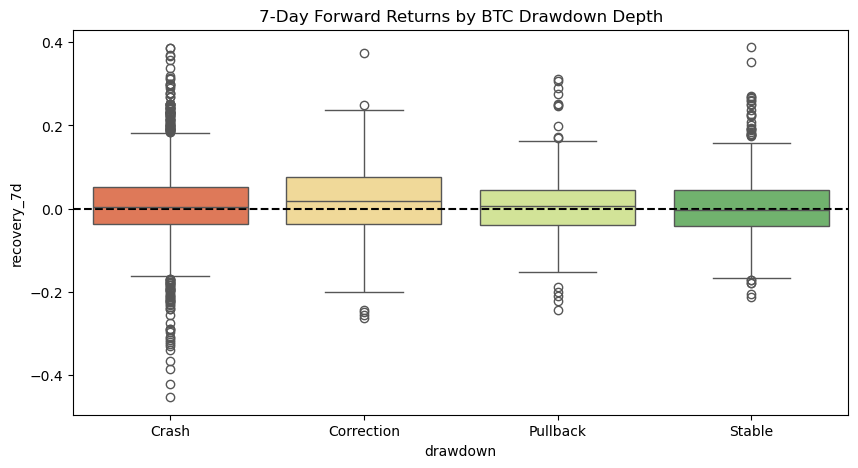

In [25]:
#  How much of the drawdown is recovered in the following 7 days?
eda['recovery_7d'] = eda['PriceUSD'].shift(-7) / eda['PriceUSD'] - 1

# Forward Return Probability based on Drawdown Depth
drawdown_buckets = pd.cut(eda['drawdown'], bins=[-1, -0.3, -0.15, -0.05, 0], labels=['Crash', 'Correction', 'Pullback', 'Stable'])

recovery_stats = eda.groupby(drawdown_buckets)['recovery_7d'].agg(['mean', 'std', 'count'])
print("BTC Recovery Velocity by Drawdown Regime:")
print(recovery_stats)

# Plotting different BTC Drawdown regimes
plt.figure(figsize=(10, 5))
sns.boxplot(x=drawdown_buckets, y=eda['recovery_7d'], palette="RdYlGn")
plt.title("7-Day Forward Returns by BTC Drawdown Depth")
plt.axhline(0, color='black', linestyle='--')
plt.show()

### Signal 1 - On Chain

Standard DCA suffers from volatility - buys aggressively during periods of peak hype and under allocate during informational vaccum. Signal 1 leverage on chain data, identifying active churn windows where price could be depressed but net|work activity suggest a good entry point. 

C:\Users\quant\AppData\Local\Temp\ipykernel_8316\1116598310.py:13: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_table = eda.pivot_table(index='mvrv_q', columns='flow_q', values='fwd_30d_ret', aggfunc='mean')


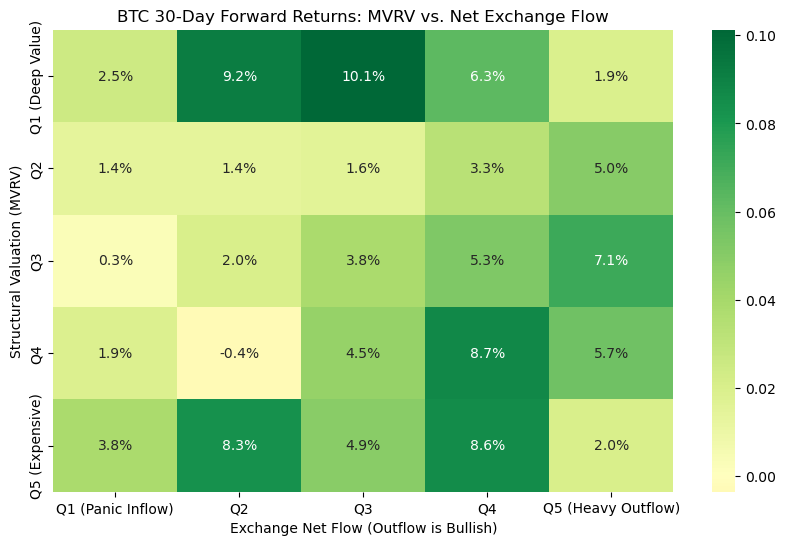

In [26]:
# 2D Binning Analysis for Signal 1 - On Chain Active Churn
# Panic extremes are less profitable than moderate churn

# 1. Prepare Features: Net Flow (Outflow - Inflow) and Active Addresses
eda['net_flow_usd'] = eda['FlowOutExUSD'] - eda['FlowInExUSD']
eda['fwd_30d_ret'] = eda['PriceUSD'].shift(-30) / eda['PriceUSD'] - 1

# 2. Create Quintiles for 2D Heatmap
eda['mvrv_q'] = pd.qcut(eda['CapMVRVCur'], 5, labels=['Q1 (Deep Value)', 'Q2', 'Q3', 'Q4', 'Q5 (Expensive)'])
eda['flow_q'] = pd.qcut(eda['net_flow_usd'], 5, labels=['Q1 (Panic Inflow)', 'Q2', 'Q3', 'Q4', 'Q5 (Heavy Outflow)'])

# 3. Aggregate Results
pivot_table = eda.pivot_table(index='mvrv_q', columns='flow_q', values='fwd_30d_ret', aggfunc='mean')

# 4. Plot
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, fmt=".1%", cmap='RdYlGn', center=0)
plt.title("BTC 30-Day Forward Returns: MVRV vs. Net Exchange Flow")
plt.xlabel("Exchange Net Flow (Outflow is Bullish)")
plt.ylabel("Structural Valuation (MVRV)")
plt.show()

# 3. Polymarket data

In [27]:
#read polymarket data
import sys
import os
import polars as pl
#from pathlib import path

sys.path.append(os.path.abspath('..'))
# Import the loader from the template provided by the project
from eda_starter_template import load_polymarket_data, POLYMARKET_DIR

# Load the dictionary of DataFrames
poly_data_dict = load_polymarket_data(POLYMARKET_DIR)

# Extract individual DataFrames for easier use
if poly_data_dict:
    df_markets = poly_data_dict.get("markets")
    df_odds = poly_data_dict.get("odds")
    df_summary = poly_data_dict.get("summary")
    
    print("Data loaded successfully!")
else:
    print("Data directory not found. Check if the 'data/Polymarket' folder exists.")

Loading Polymarket data from C:\Users\quant\Trilemma\bitcoin-analytics-capstone-sp26-team08\data\Polymarket...
[Memory] Before loading Polymarket data: 251.73 MB
Loaded 78321 markets.
Loaded 2143181 odds history records.
Loaded 78321 summary records.
[Memory] After loading Polymarket data: 463.15 MB (Δ 211.42 MB)
Data loaded successfully!


In [28]:
df_markets.head()

market_id,question,slug,event_slug,category,volume,active,closed,created_at,end_date
str,str,str,str,str,f64,bool,bool,datetime[μs],datetime[μs]
"""242851""","""Will Bongbong Marcos be electe…","""will-bongbong-marcos-be-electe…","""will-bongbong-marcos-be-electe…","""Global Politics""",21533.53,true,true,2022-04-05 20:37:30,2022-05-09 00:00:00
"""242873""","""Will Sarah Palin win Alaska's …","""will-sarah-palin-win-in-the-al…","""will-sarah-palin-win-in-the-al…","""US-current-affairs""",79783.23,true,true,2022-04-05 22:41:57,2022-08-16 00:00:00
"""242918""","""Will US student loan payments …","""will-us-student-loan-payments-…","""will-us-student-loan-payments-…","""US-current-affairs""",18946.72,true,true,2022-04-05 23:33:47,2022-11-08 00:00:00
"""243183""","""Will $ETH be above $3,000 on A…","""will-eth-be-above-3000-on-apri…","""will-eth-be-above-3000-on-apri…","""Crypto""",974114.26,true,true,2022-04-12 16:51:10,2022-04-20 00:00:00
"""243192""","""Will Brian Kemp win the Republ…","""will-brian-kemp-win-the-republ…","""who-will-win-the-republican-no…","""US-current-affairs""",7024.92,true,true,2022-04-13 01:40:25,2022-05-24 00:00:00


In [29]:
unique_categories = df_markets['category'].unique()
print(unique_categories)

shape: (11,)
Series: 'category' [str]
[
	"Global Politics"
	"Business"
	"Tech"
	"Politics"
	"Ukraine & Russia"
	…
	"US-current-affairs"
	""
	"Pop-Culture "
	"Coronavirus-"
	"Crypto"
]


In [30]:
tokens_path = POLYMARKET_DIR / "finance_politics_tokens.parquet"
event_path = POLYMARKET_DIR / "finance_politics_event_stats.parquet"
trades_path = POLYMARKET_DIR / "finance_politics_trades.parquet"

df_tokens = (
    pl.scan_parquet(tokens_path)
    .collect()
)
df_event = (
    pl.scan_parquet(event_path)
    .collect()
)

if trades_path.exists():
    trades_df = pl.scan_parquet(trades_path).collect()
    
    # Fix timestamp corruption
    for col in trades_df.columns:
        if any(x in col.lower() for x in ["timestamp", "trade", "created_at", "end_date"]):
            if trades_df[col].dtype == pl.Datetime or trades_df[col].dtype == pl.Date:
                if not trades_df[col].is_empty() and trades_df[col].max() < datetime(2020, 1, 1):
                    trades_df = trades_df.with_columns((pl.col(col).cast(pl.Int64) * 1000).cast(pl.Datetime))
                    
            # Enforce 2020+ constraint (replace placeholders/zeros with null)
            if trades_df[col].dtype == pl.Datetime or trades_df[col].dtype == pl.Date:
                    trades_df = trades_df.with_columns(
                        pl.when(pl.col(col) < datetime(2020, 1, 1))
                        .then(None)
                        .otherwise(pl.col(col))
                        .alias(col)
                    )
                
    print(f"Loaded {len(trades_df)} trades records.")

Loaded 27013724 trades records.


In [31]:
df_markets
# Filter for rows where both are True
both_true = df_markets.filter(
    (pl.col("active") == True) & (pl.col("closed") == True)
)

print(f"Total Markets: {len(df_markets)}")
print(f"Markets with (active=True AND closed=True): {len(both_true)}")

Total Markets: 78321
Markets with (active=True AND closed=True): 73200


# 3.1 Markets

In [32]:
df_markets.head()

#find unique category
df_markets['category'].unique()
search_list = ["bitcoin", "btc","crypto","blockchain",'ETH']
# filter crypto related event, and general political event
crypto_markets = df_markets.filter(
    (pl.col("category").str.to_lowercase().str.contains_any([ "Crypto", 'Business','Politics','US-current-affairs'])) |
    (pl.col("question").str.to_lowercase().str.contains_any(search_list, ascii_case_insensitive=True))
)

crypto_markets['category'].unique()

#check aggregated newly created daily market
daily_pm_features = (
    crypto_markets
    .filter(pl.col("created_at").is_not_null())
    .group_by(pl.col("created_at").dt.date().alias("date"))
    .agg([
        pl.count("market_id").alias("pm_new_market_count"),
        pl.col("volume").sum().alias("pm_daily_volume"),
        # average days the market remain active
        ((pl.col("end_date") - pl.col("created_at")).dt.total_days()).mean().alias("avg_market_duration")
    ])
    .sort("date")
)

# Convert to pandas 
pm_features_pd = daily_pm_features.to_pandas()
pm_features_pd['date'] = pd.to_datetime(pm_features_pd['date'])

# 

Correlation between BTC and Polymarket Activity:
                     PriceUSD   vol_30d  pm_new_market_count  pm_daily_volume
PriceUSD             1.000000 -0.495826             0.514011         0.426008
vol_30d             -0.495826  1.000000            -0.352249        -0.215882
pm_new_market_count  0.514011 -0.352249             1.000000         0.455843
pm_daily_volume      0.426008 -0.215882             0.455843         1.000000


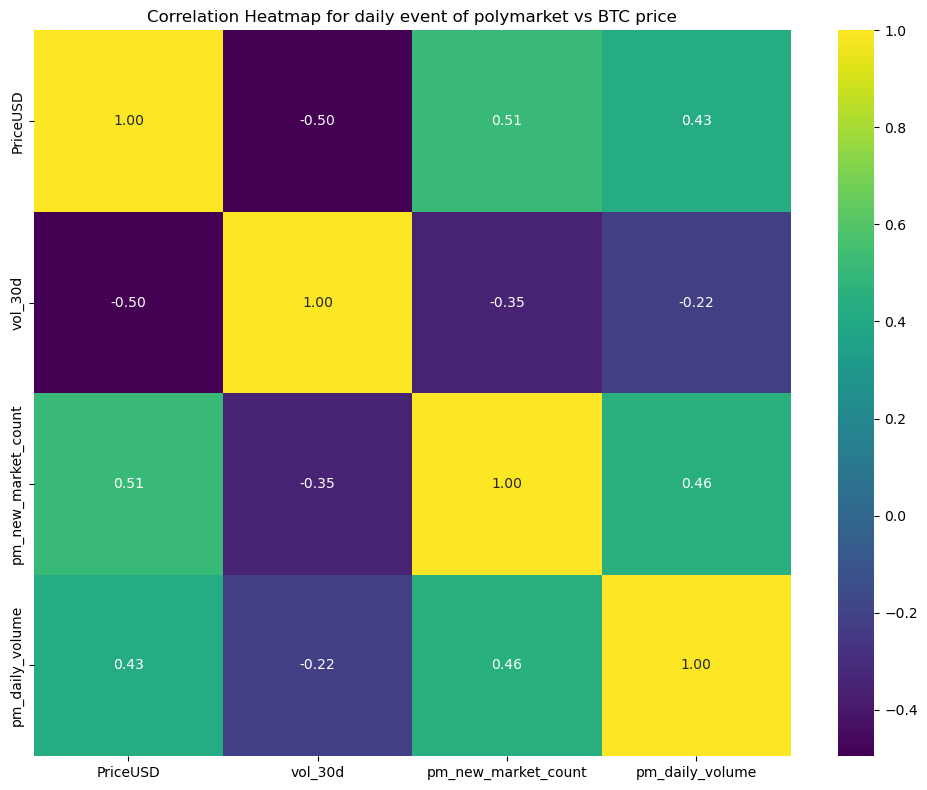

In [33]:
# combine markets with btc price data
btc_daily = eda.reset_index().rename(columns={'time':'date'})
btc_daily['date'] = btc_daily['date'].dt.normalize()

#merge the daily aggregated polymarket features with BTC price and vol
merged_markets_btc = btc_daily.merge(pm_features_pd,on='date',how='inner')

#correlation matrix
cols_to_corr = ['PriceUSD', 'vol_30d', 'pm_new_market_count', 'pm_daily_volume']
print("Correlation between BTC and Polymarket Activity:")
corr = merged_markets_btc[cols_to_corr].corr()
print(corr)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="viridis", fmt=".2f")
plt.title("Correlation Heatmap for daily event of polymarket vs BTC price")
plt.tight_layout()
plt.show()

In [34]:
#investigate any lead lag relationship
merged_markets_btc['pm_count_lag1'] = merged_markets_btc['pm_new_market_count'].shift(1)

# Calculate correlation with Price Change (Returns) instead of absolute Price
merged_markets_btc['ret_1d'] = merged_markets_btc['PriceUSD'].pct_change()

lead_corr = merged_markets_btc[['ret_1d', 'pm_count_lag1']].corr()
print("Whether yesterday's PM activity predict today's BTC return?")
print(lead_corr)

Whether yesterday's PM activity predict today's BTC return?
                 ret_1d  pm_count_lag1
ret_1d         1.000000      -0.060899
pm_count_lag1 -0.060899       1.000000


Top 10 Macro Event Clusters by Volume:
shape: (10, 6)
┌─────────────────┬─────────────────┬─────────────────┬──────────┬────────────────┬────────────────┐
│ event_slug      ┆ total_event_vol ┆ sub_market_coun ┆ %_active ┆ start_date     ┆ end_date       │
│ ---             ┆ ume             ┆ t               ┆ ---      ┆ ---            ┆ ---            │
│ str             ┆ ---             ┆ ---             ┆ f64      ┆ datetime[μs]   ┆ datetime[μs]   │
│                 ┆ f64             ┆ u32             ┆          ┆                ┆                │
╞═════════════════╪═════════════════╪═════════════════╪══════════╪════════════════╪════════════════╡
│ presidential-el ┆ 3.6863e9        ┆ 17              ┆ 1.0      ┆ 2024-01-04     ┆ 2024-11-05     │
│ ection-winner-2 ┆                 ┆                 ┆          ┆ 17:33:51       ┆ 12:00:00       │
│ …               ┆                 ┆                 ┆          ┆                ┆                │
│ presidential-el ┆ 6.2816e8        ┆

C:\Users\quant\AppData\Local\Temp\ipykernel_8316\706763173.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=event_clusters.to_pandas(), x="total_event_volume", y="event_slug", palette="viridis")


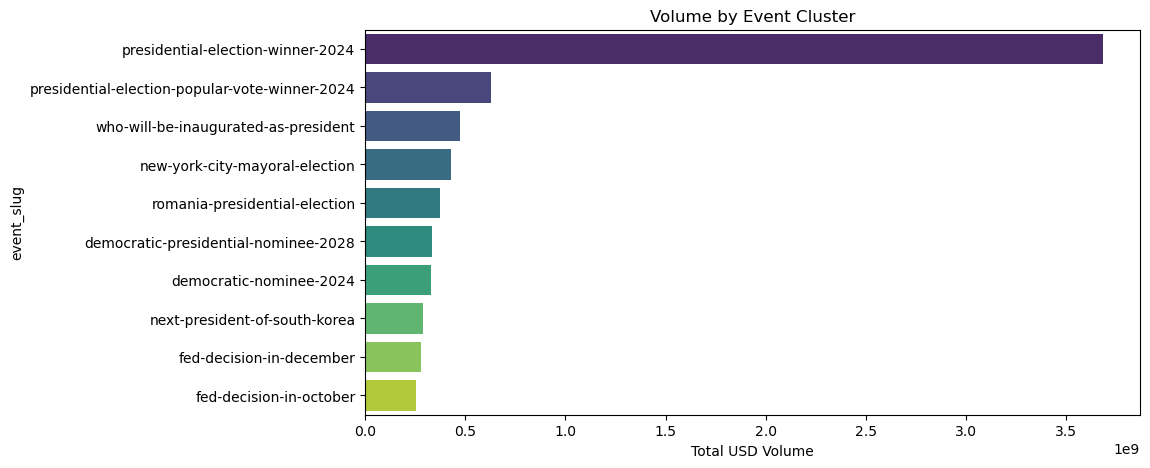

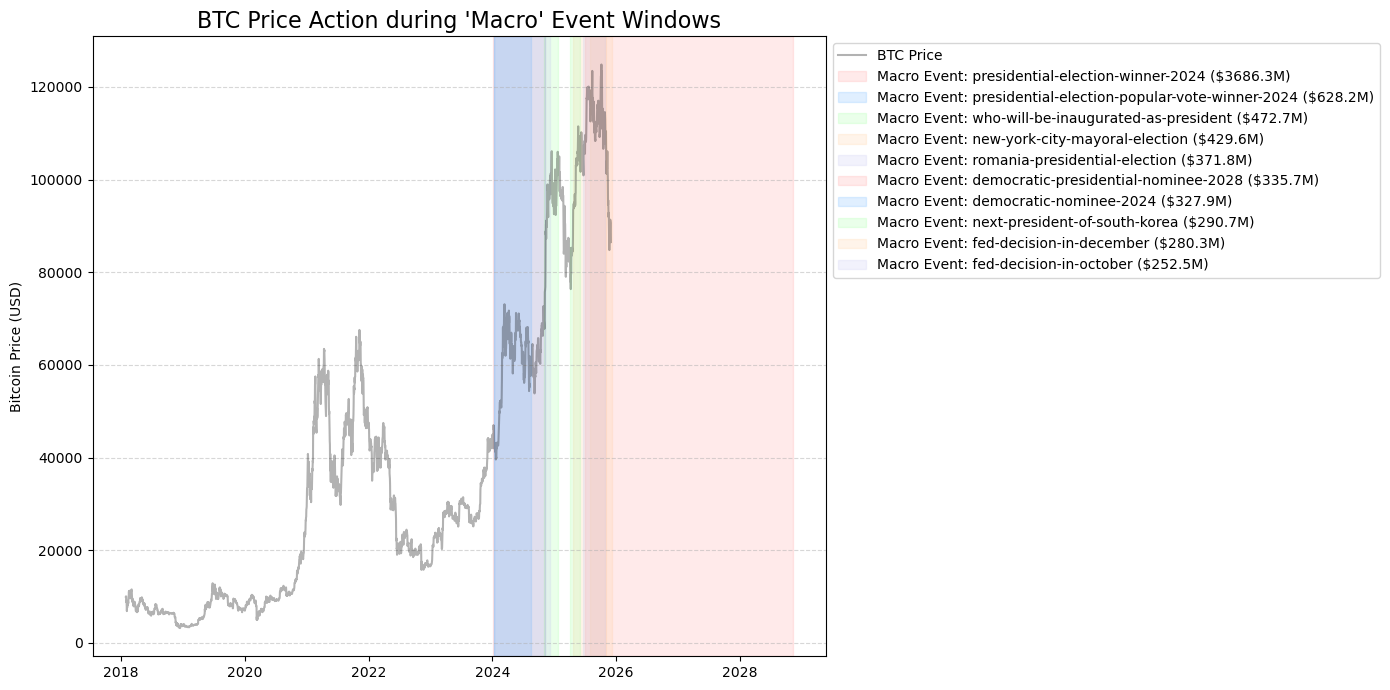

In [35]:
# Check event slug level
#1 event cluster shows election tops the chart (as expected)
event_clusters = (
    df_markets
    .group_by("event_slug")
    .agg([
        pl.col("volume").sum().alias("total_event_volume"),
        pl.count("market_id").alias("sub_market_count"),
        pl.col("active").mean().alias("%_active"),
        pl.col("created_at").min().alias("start_date"),
        pl.col("end_date").max().alias("end_date")
    ])
    .sort("total_event_volume", descending=True)
    .head(10) 
)

print("Top 10 Macro Event Clusters by Volume:")
print(event_clusters)

# Visualization of Event Clusters
plt.figure(figsize=(10, 5))
sns.barplot(data=event_clusters.to_pandas(), x="total_event_volume", y="event_slug", palette="viridis")
plt.title("Volume by Event Cluster")
plt.xlabel("Total USD Volume")
plt.show()

#2 plot BTC price
plt.figure(figsize=(14, 7))

# Plot BTC Price
plt.plot(btc_daily['date'], btc_daily['PriceUSD'], color='black', alpha=0.3, label='BTC Price')
plt.ylabel("Bitcoin Price (USD)")

#3 overlay the cluster, check btc movement during big macro event
colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99', '#c2c2f0']

for i, row in enumerate(event_clusters.to_dicts()):
    # Convert to pandas timestamps for plotting
    start = pd.to_datetime(row['start_date'])
    end = pd.to_datetime(row['end_date'])
    
    # Shade the area where this Macro event was active
    plt.axvspan(start, end, alpha=0.2, color=colors[i % len(colors)], 
                label=f"Macro Event: {row['event_slug']} (${row['total_event_volume']/1e6:.1f}M)")

plt.title("BTC Price Action during 'Macro' Event Windows", fontsize=16)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

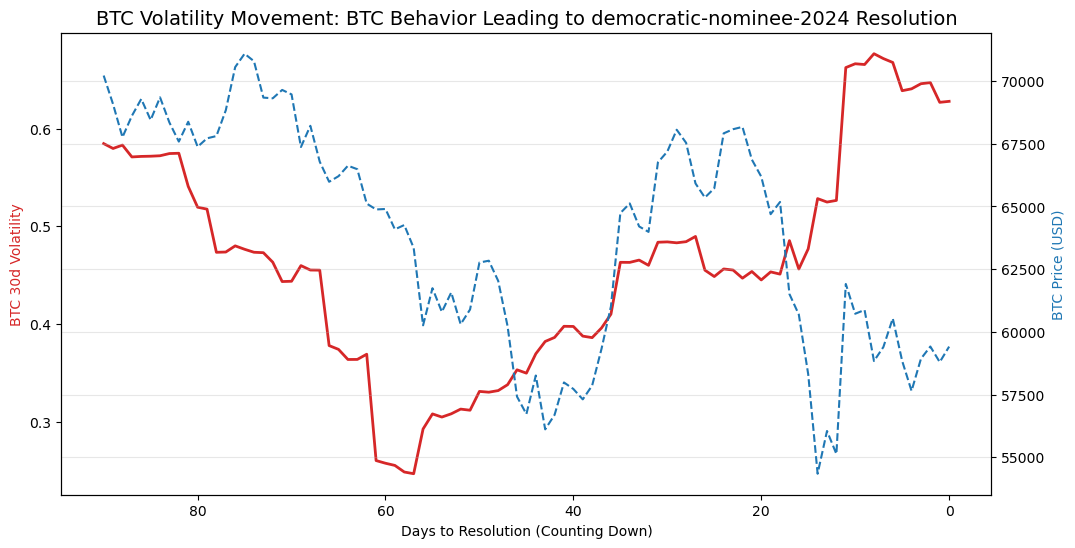

In [36]:
#Check volatility change when event approaches the end

major_slug = event_clusters['event_slug'][6] 

magnet_markets = df_markets.filter(pl.col("event_slug") == major_slug)

# 2. Calculate "Days to Resolution" for each day in history
# We join the BTC daily dates with the event's end date
resolution_date = magnet_markets['end_date'].max()

btc_pressure = btc_daily.copy()
btc_pressure['days_to_res'] = (pd.to_datetime(resolution_date) - pd.to_datetime(btc_pressure['date'])).dt.days

# Filter to only show the 90 days leading up to the resolution
btc_pressure = btc_pressure[(btc_pressure['days_to_res'] >= 0) & (btc_pressure['days_to_res'] <= 90)]

# 3. Plot Volatility vs Countdown
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.set_xlabel('Days to Resolution (Counting Down)')
ax1.set_ylabel('BTC 30d Volatility', color='tab:red')
ax1.plot(btc_pressure['days_to_res'], btc_pressure['vol_30d'], color='tab:red', linewidth=2)
ax1.invert_xaxis() # Countdown from 90 to 0

ax2 = ax1.twinx()
ax2.set_ylabel('BTC Price (USD)', color='tab:blue')
ax2.plot(btc_pressure['days_to_res'], btc_pressure['PriceUSD'], color='tab:blue', linestyle='--')

plt.title(f"BTC Volatility Movement: BTC Behavior Leading to {major_slug} Resolution", fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

# 3.2 Tokens

In [37]:
df_tokens

market_id,token_id,outcome
str,str,str
"""240383""","""555875344331027638590324435858…","""Yes"""
"""240383""","""111837615529992437689409005124…","""No"""
"""240384""","""113459643164060403919504712048…","""Yes"""
"""240384""","""110606609354376812966157988257…","""No"""
"""240385""","""505435736314143687770680977181…","""Yes"""
…,…,…
"""892920""","""496224936867145107714728324950…","""Down"""
"""892921""","""116918525891988714423444796180…","""Up"""
"""892921""","""827298723842613390623635576167…","""Down"""


In [38]:
df_tokens.select("outcome").unique()

outcome
str
"""Coalition"""
"""Over 2%"""
"""107k"""
"""Green Bay Phoenix"""
"""D'Esposito"""
…
"""Samford Bulldogs"""
"""Do Kwon"""
"""Pedro Castillo"""


# 3.3 Event

In [39]:
df_event.head()

event_slug,market_count,total_volume,first_market_start,last_market_end
str,i64,f64,datetime[μs],datetime[μs]
"""will-binancecom-become-insolve…",1,269.41,2023-01-24 21:09:31,2023-02-28 00:00:00
"""gme-market-cap-on-may-17""",7,112281.62,2024-05-13 17:51:35,2024-05-17 12:00:00
"""republican-vp-nominee""",25,9.2566e7,2024-01-18 19:14:19,2024-09-08 12:00:00
"""will-kevin-mccarthy-resign-fro…",1,6410.89,2023-11-12 19:11:54,2023-11-30 00:00:00
"""safe-market-cap-fdv-one-week-a…",6,116716.82,2024-03-26 17:01:59,2024-12-31 12:00:00


In [40]:
df_event.describe()

statistic,event_slug,market_count,total_volume,first_market_start,last_market_end
str,str,f64,f64,str,str
"""count""","""44033""",44033.0,44033.0,"""44033""","""43886"""
"""null_count""","""0""",0.0,0.0,"""0""","""147"""
"""mean""",null,1.778689,413405.874334,"""2025-08-22 22:37:19.378284""","""2025-09-02 02:30:29.852344"""
"""std""",null,2.786778,1.8830e7,null,null
"""min""","""1-searched-person-on-google-th…",1.0,0.0,"""2020-10-02 16:10:01""","""2020-01-01 00:00:00"""
"""25%""",null,1.0,3217.403669,"""2025-08-28 09:18:16""","""2025-09-03 16:00:00"""
"""50%""",null,1.0,17087.824062,"""2025-10-13 00:00:08""","""2025-10-15 16:30:00"""
"""75%""",null,1.0,57651.021299,"""2025-11-12 21:06:23""","""2025-11-15 14:45:00"""
"""max""","""zohran-mamdani-of-vote-in-2025…",69.0,3.6863e9,"""2025-12-10 05:32:21""","""2028-11-07 00:00:00"""


In [41]:
# df_event convert to daily event activity
# --- 1) Ensure df_event is pandas + datetime types (force UTC tz-aware) ---
df_event = pd.DataFrame(df_event.to_dict(as_series=False))

df_event["first_market_start"] = pd.to_datetime(
    df_event["first_market_start"], utc=True, errors="coerce")
df_event["last_market_end"] = pd.to_datetime(
    df_event["last_market_end"], utc=True, errors="coerce")

# --- 2) Create daily date range based on BTC df (force UTC tz-aware daily index) ---
daily_index = pd.DatetimeIndex(df.index)

# make sure BTC index is UTC tz-aware
if daily_index.tz is None:
    daily_index = daily_index.tz_localize("UTC")
else:
    daily_index = daily_index.tz_convert("UTC")

daily_index = daily_index.normalize()  # daily dates in UTC

# --- 3) Build daily event activity signals ---
active_event_count = pd.Series(0, index=daily_index, dtype="int64")
active_volume_sum  = pd.Series(0.0, index=daily_index, dtype="float64")
active_market_sum  = pd.Series(0.0, index=daily_index, dtype="float64")

for _, row in df_event.dropna(subset=["first_market_start", "last_market_end"]).iterrows():
    start = row["first_market_start"].normalize()
    end   = row["last_market_end"].normalize()

    # clip to BTC date range 
    if end < daily_index.min() or start > daily_index.max():
        continue

    start = max(start, daily_index.min())
    end   = min(end, daily_index.max())

    mask = (daily_index >= start) & (daily_index <= end)
    active_event_count.loc[mask] += 1
    active_volume_sum.loc[mask]  += float(row["total_volume"]) if pd.notna(row["total_volume"]) else 0.0
    active_market_sum.loc[mask]  += float(row["market_count"]) if pd.notna(row["market_count"]) else 0.0

df_event_daily = pd.DataFrame({
    "active_event_count": active_event_count,
    "active_volume_sum": active_volume_sum,
    "active_market_sum": active_market_sum
})

# log scale for volume to reduce extreme skew
df_event_daily["log_active_volume_sum"] = np.log1p(df_event_daily["active_volume_sum"])

# --- 4) Merge with BTC daily features (force BTC daily index to match daily_index) ---
btc_daily = df.copy()

btc_daily.index = pd.DatetimeIndex(btc_daily.index)
if btc_daily.index.tz is None:
    btc_daily.index = btc_daily.index.tz_localize("UTC")
else:
    btc_daily.index = btc_daily.index.tz_convert("UTC")

btc_daily.index = btc_daily.index.normalize()

df_merged = btc_daily.join(df_event_daily, how="left").fillna(0)

df_merged.head()

,AdrActCnt,AdrBalCnt,AssetCompletionTime,AssetEODCompletionTime,BlkCnt,CapMVRVCur,CapMrktCurUSD,CapMrktEstUSD,FeeTotNtv,FlowInExNtv,...,price_vs_ma200,drawdown,net_flow_usd,fwd_ret_30d,fwd_vol_30d,fwd_min_dd_30d,active_event_count,active_volume_sum,active_market_sum,log_active_volume_sum
time,,,,,,,,,,,,,,,,,,,,,
2018-01-01 00:00:00+00:00,972783.0,26829117.0,1.614337e+09,1.614337e+09,156.0,2.694235,2.258877e+11,0.0,477.225170,36000.622080,...,0.0,0.0,1.291811e+08,-0.253594,0.0,0.0,0,0.0,0.0,0.0
2018-01-02 00:00:00+00:00,1142721.0,26909375.0,1.614337e+09,1.614337e+09,171.0,2.925443,2.475552e+11,0.0,649.878138,65831.310897,...,0.0,0.0,-2.480938e+08,-0.387307,0.0,0.0,0,0.0,0.0,0.0
2018-01-03 00:00:00+00:00,1130917.0,27133378.0,1.614337e+09,1.614337e+09,157.0,2.960267,2.518793e+11,0.0,750.020447,56969.474964,...,0.0,0.0,-1.441119e+08,-0.414663,0.0,0.0,0,0.0,0.0,0.0
2018-01-04 00:00:00+00:00,1253986.0,27415056.0,1.614337e+09,1.614337e+09,168.0,2.944022,2.529181e+11,0.0,777.017867,77816.063305,...,0.0,0.0,-8.682248e+07,-0.394033,0.0,0.0,0,0.0,0.0,0.0
2018-01-05 00:00:00+00:00,1069525.0,27645350.0,1.614337e+09,1.614337e+09,143.0,3.261964,2.852872e+11,0.0,704.313737,72765.218396,...,0.0,0.0,-3.374689e+07,-0.514596,0.0,0.0,0,0.0,0.0,0.0


### Signal 2.1

Bitcoin's volatility "compresses" as a major macro event on Polymarket reaches its conclusion. Check the vol move for top 100 events.
Market becomes efficient and narrow close to resolution, the model will dampen signal aggresion.

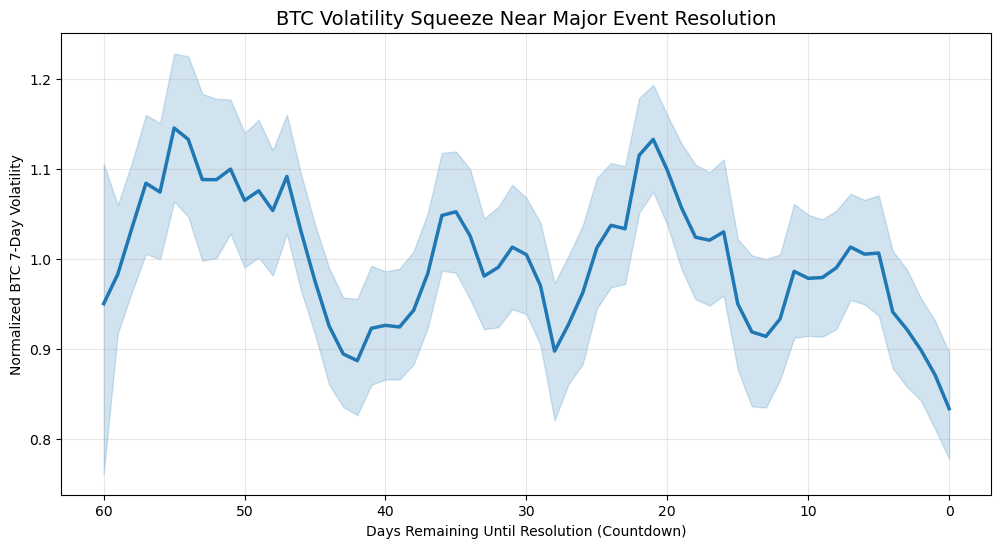

In [42]:
def plot_macro_volatility_squeeze(btc_df, event_df, lookback_days=60):
    btc_df = btc_df.copy()
    # Ensure BTC index is naive
    if btc_df.index.tz is not None:
        btc_df.index = btc_df.index.tz_localize(None)
        
    # Ensure Event columns are naive
    event_df = event_df.copy()
    event_df['last_market_end'] = pd.to_datetime(event_df['last_market_end']).dt.tz_localize(None)
    event_df['first_market_start'] = pd.to_datetime(event_df['first_market_start']).dt.tz_localize(None)

    # --- 2. Calculate BTC Volatility ---
    btc_df['log_ret'] = np.log(btc_df['PriceUSD'] / btc_df['PriceUSD'].shift(1))
    btc_df['vol_7d'] = btc_df['log_ret'].rolling(7).std()
    
    # --- 3. Identify Top 10 'Anchor' Events ---
    top_anchors = event_df.sort_values("total_volume", ascending=False).head(100)
    
    all_event_windows = []
    
    for _, event in top_anchors.iterrows():
        # Double check the single timestamp is naive
        res_date = event['last_market_end']
        start_date = res_date - pd.Timedelta(days=lookback_days)
        
        # Now the comparison (index vs start/end) will work
        mask = (btc_df.index >= start_date) & (btc_df.index <= res_date)
        window = btc_df.loc[mask].copy()
        
        if not window.empty:
            window['days_to_res'] = (res_date - window.index).days
            window['event_slug'] = event['event_slug']
            # Normalize for cross-event comparison
            window['norm_vol'] = window['vol_7d'] / window['vol_7d'].mean()
            
            all_event_windows.append(window[['days_to_res', 'norm_vol', 'event_slug']])

    if not all_event_windows:
        print("No overlapping data found. Check date ranges.")
        return

    plot_df = pd.concat(all_event_windows)

    # --- 4. Plot ---
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=plot_df, x='days_to_res', y='norm_vol', 
                 errorbar=('ci', 95), color='tab:blue', linewidth=2.5)
    
    plt.gca().invert_xaxis() 
    plt.title("BTC Volatility Squeeze Near Major Event Resolution", fontsize=14)
    plt.xlabel("Days Remaining Until Resolution (Countdown)")
    plt.ylabel("Normalized BTC 7-Day Volatility")
    plt.grid(True, alpha=0.3)
    plt.show()


plot_macro_volatility_squeeze(btc_daily, df_event)

In [43]:
#duration
df_event["first_market_start"] = pd.to_datetime(df_event["first_market_start"])
df_event["last_market_end"] = pd.to_datetime(df_event["last_market_end"])

# Calculate duration
df_event["duration_days"] = (
    df_event["last_market_end"] - df_event["first_market_start"]
).dt.days


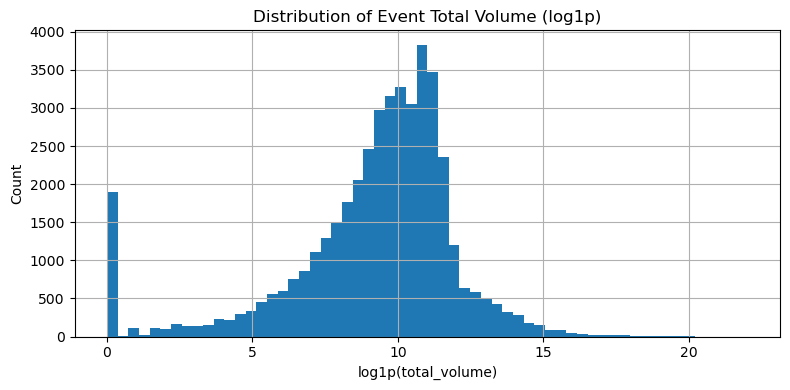

In [44]:
#event distribution of volume
plt.figure(figsize=(8,4))
plt.hist(np.log1p(df_event["total_volume"]), bins=60)
plt.title("Distribution of Event Total Volume (log1p)")
plt.xlabel("log1p(total_volume)")
plt.ylabel("Count")
plt.grid(True)
plt.tight_layout()
plt.savefig("plots/event_volume_distribution.png", dpi=300, bbox_inches="tight")
plt.show()
# There is a very tall bar on the left, which means many total_volume values are very small 
# (even close to 0); these events are almost pure noise when you measure “activity intensity”: 
# either nobody is trading, or data quality/market activity is too low.
# The main mass sits in the middle, but there is a long tail on the right,  
# means a small number of events have extremely large traded volume  
# This will cause the “high-quantile group” in a quintile split using qcut to be almost entirely dominated by these mega events, 
# while the differences among Q1–Q4 may become quite small.

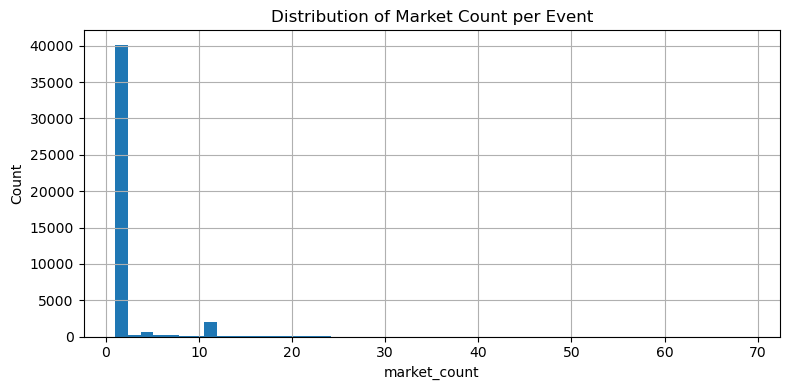

In [45]:
plt.figure(figsize=(8,4))
plt.hist(df_event["market_count"], bins=50)
plt.title("Distribution of Market Count per Event")
plt.xlabel("market_count")
plt.ylabel("Count")
plt.grid(True)
plt.tight_layout()
plt.savefig("plots/Distribution of Market Count per Event.png", dpi=300, bbox_inches="tight")
plt.show()
# Large spike, most event has smaller amount of markets

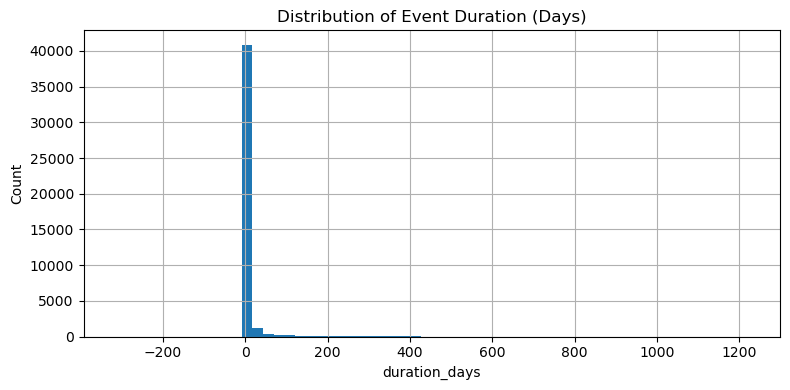

In [46]:
plt.figure(figsize=(8,4))
plt.hist(df_event["duration_days"], bins=60)
plt.title("Distribution of Event Duration (Days)")
plt.xlabel("duration_days")
plt.ylabel("Count")
plt.grid(True)
plt.tight_layout()
plt.savefig("plots/Distribution of Event Duration (Days).png", dpi=300, bbox_inches="tight")
plt.show()
# duration has a long bar and tail
# Hot event would accumulate more trading volume the longer it lasts

In [47]:
top_events = df_event.sort_values("total_volume", ascending=False).head(10)
top_events[["event_slug","market_count","total_volume","duration_days"]]
# top10 events（winner、popular vote、inauguration），local election（NYC mayor），Fed （Oct/Dec）etc
# Largest volume all related to macro and political event

,event_slug,market_count,total_volume,duration_days
6000,presidential-election-winner-2024,17,3.686335e+09,305.0
3226,presidential-election-popular-vote-winner-2024,17,6.281635e+08,300.0
16312,who-will-be-inaugurated-as-president,2,4.726567e+08,79.0
1227,new-york-city-mayoral-election,12,4.296144e+08,195.0
3642,romania-presidential-election,6,3.718380e+08,30.0
17588,democratic-presidential-nominee-2028,38,3.356896e+08,1222.0
3627,democratic-nominee-2024,9,3.278662e+08,223.0
432,next-president-of-south-korea,19,2.907458e+08,59.0
34746,fed-decision-in-december,4,2.802709e+08,131.0
5641,fed-decision-in-october,4,2.524856e+08,131.0


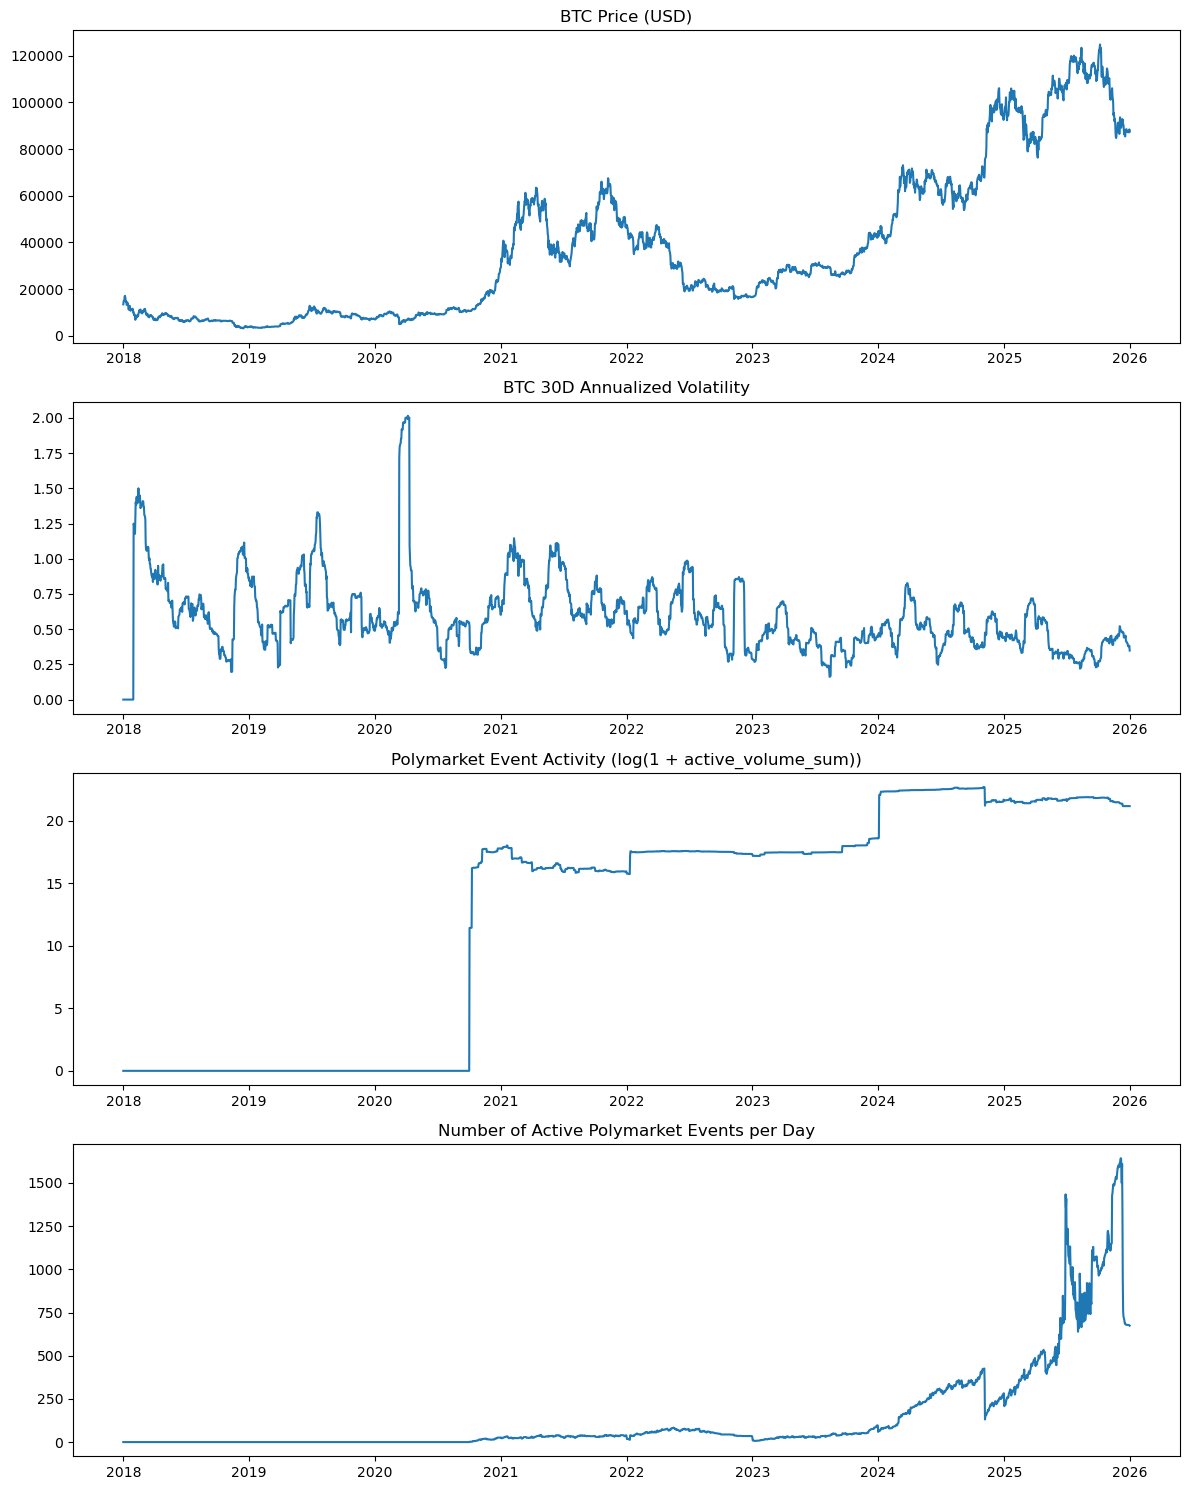

In [48]:
fig = plt.figure(figsize=(12, 15))
ax1 = fig.add_subplot(4, 1, 1)
ax2 = fig.add_subplot(4, 1, 2, sharex=ax1)
ax3 = fig.add_subplot(4, 1, 3, sharex=ax1)
ax4 = fig.add_subplot(4, 1, 4, sharex=ax1)

ax1.plot(df_merged.index, df_merged["PriceUSD"])
ax1.set_title("BTC Price (USD)")

ax2.plot(df_merged.index, df_merged["vol_30d"])
ax2.set_title("BTC 30D Annualized Volatility")

ax3.plot(df_merged.index, df_merged["log_active_volume_sum"])
ax3.set_title("Polymarket Event Activity (log(1 + active_volume_sum))")

ax4.plot(df_merged.index, df_merged["active_event_count"])
ax4.set_title("Number of Active Polymarket Events per Day")

plt.tight_layout()
plt.show()

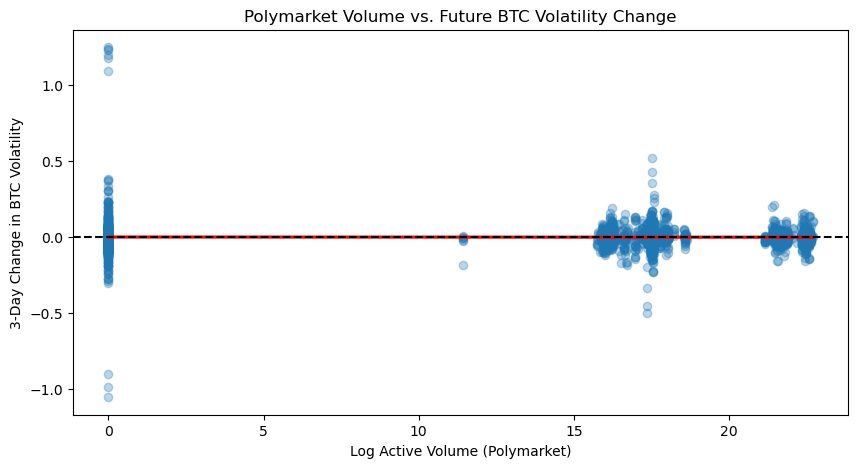

In [49]:
# Calculate correlation between Volume and Future Volatility
df_merged['fwd_vol_delta'] = df_merged['vol_30d'].shift(-3) - df_merged['vol_30d']

plt.figure(figsize=(10, 5))
sns.regplot(data=df_merged, x='log_active_volume_sum', y='fwd_vol_delta', 
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title("Polymarket Volume vs. Future BTC Volatility Change")
plt.xlabel("Log Active Volume (Polymarket)")
plt.ylabel("3-Day Change in BTC Volatility")
plt.axhline(0, color='black', linestyle='--')
plt.savefig("vol_absorption_reg.png")

In [50]:
# future
df_merged["fwd_ret_30d"] = (
    df_merged["PriceUSD"].shift(-30) /
    df_merged["PriceUSD"] - 1
)
df_merged["fwd_vol_30d"] = (
    df_merged["vol_30d"]
    .shift(-1)
    .rolling(30)
    .mean()
)
df_merged["fwd_drawdown_30d"] = (
    df_merged["drawdown"]
    .shift(-1)
    .rolling(30)
    .min()
)
df_merged["dd_lt_20pct"] = (
    df_merged["fwd_drawdown_30d"] < -0.20
).astype(int)

# Initialize all days as "No_Event"
df_merged["event_regime"] = "No_Event"

# Identify days with positive Polymarket event activity
mask = df_merged["log_active_volume_sum"] > 0

# For active-event days, bucket event intensity into quintiles
df_merged.loc[mask, "event_regime"] = pd.qcut(
    df_merged.loc[mask, "log_active_volume_sum"],
    q=5,
    labels=[f"Q{i}" for i in range(1, 6)]
).astype(str)

df_merged["event_quintile"] = df_merged["event_regime"]
df_merged["event_quintile"].value_counts(dropna=False)

event_quintile
No_Event    1005
Q2           408
Q1           386
Q5           384
Q4           380
Q3           359
Name: count, dtype: int64

In [51]:
event_table = (
    df_merged
    .dropna(subset=[
        "event_quintile",
        "fwd_ret_30d",
        "fwd_vol_30d",
        "fwd_drawdown_30d"
    ])
    .groupby("event_quintile")
    .agg(
        avg_fwd_ret_30d=("fwd_ret_30d", "mean"),
        avg_fwd_vol_30d=("fwd_vol_30d", "mean"),
        prob_dd_lt_20pct=("dd_lt_20pct", "mean") 
    )
    .reset_index()
)

# Signal 2.2 
Lack of event could be dangerous. When polymarket has no or low active events, it may signal a lack of market direction or impending vol crush

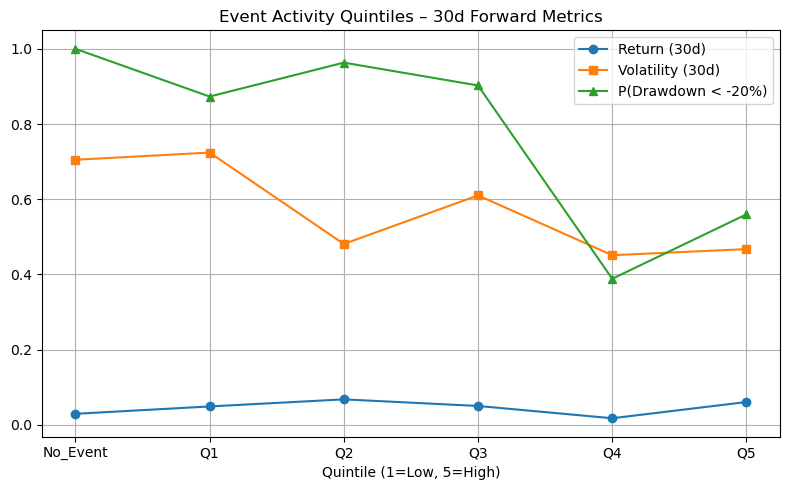

In [52]:
fig, ax = plt.subplots(figsize=(8,5))

ax.plot(event_table["event_quintile"],
        event_table["avg_fwd_ret_30d"],
        marker="o", label="Return (30d)")

ax.plot(event_table["event_quintile"],
        event_table["avg_fwd_vol_30d"],
        marker="s", label="Volatility (30d)")

ax.plot(event_table["event_quintile"],
        event_table["prob_dd_lt_20pct"],
        marker="^", label="P(Drawdown < -20%)")

ax.set_title("Event Activity Quintiles – 30d Forward Metrics")
ax.set_xlabel("Quintile (1=Low, 5=High)")
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.savefig("plots/event_quintile_forward_metrics.png", 
            dpi=300, 
            bbox_inches="tight")
plt.show()

C:\Users\quant\AppData\Local\Temp\ipykernel_8316\1131874954.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  crash_prob = df_merged.groupby('event_bin')['is_crash_regime'].mean()


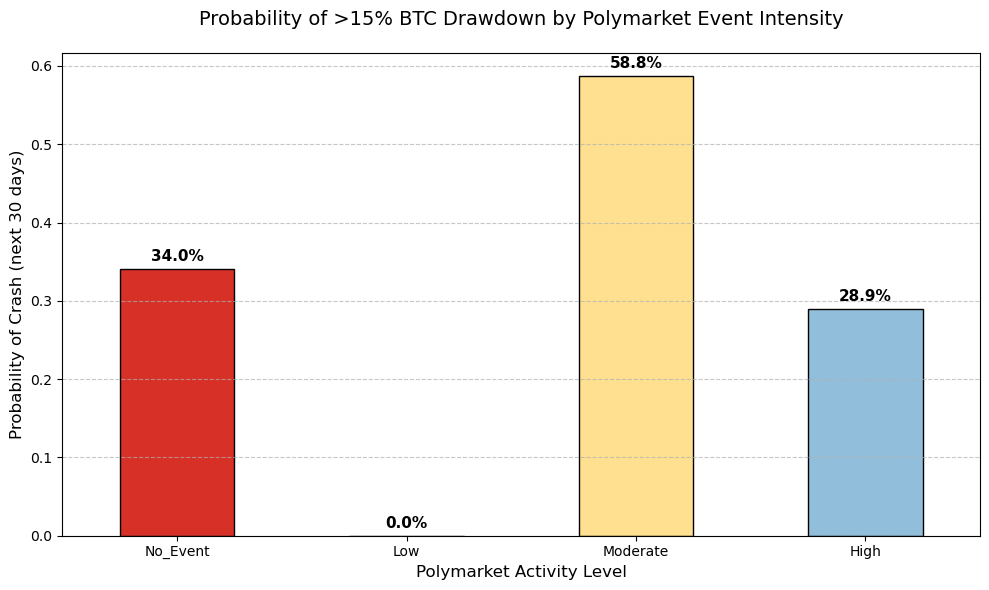

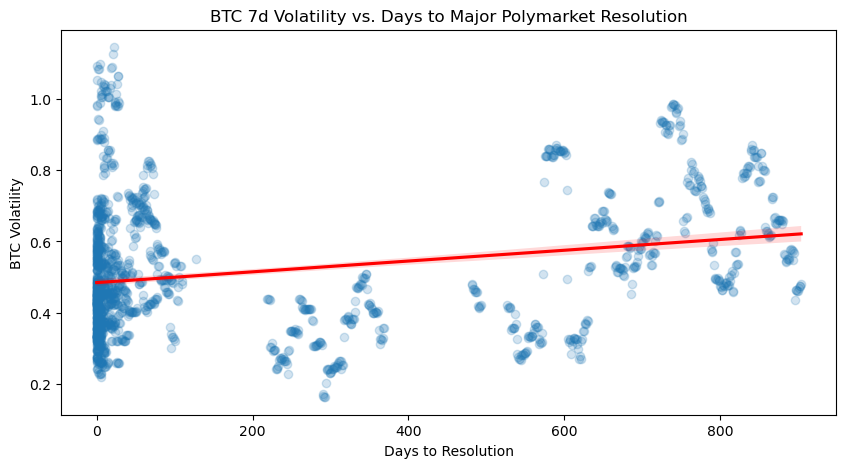

In [53]:
#  Signal 2.2: Event Activity Gate 
df_merged['fwd_30d_min_ret'] = df_merged['PriceUSD'].shift(-7).rolling(window=30).min() / df_merged['PriceUSD'] - 1
df_merged['is_crash_regime'] = (df_merged['fwd_30d_min_ret'] < -0.15).astype(int)

# Group by active event count to show 'No Event' risk
# We treat 0 as 'No Event' and bin the rest
df_merged['event_bin'] = pd.cut(df_merged['active_event_count'], 
                                bins=[-1, 0, 5, 15, 100], 
                                labels=['No_Event', 'Low', 'Moderate', 'High'])

crash_prob = df_merged.groupby('event_bin')['is_crash_regime'].mean()

# Plotting the crash probability
plt.figure(figsize=(10, 6))
colors = ['#d73027', '#fc8d59', '#fee090', '#91bfdb'] # Red for 'No_Event' to Blue for 'High'
ax = crash_prob.plot(kind='bar', color=colors, edgecolor='black')

plt.title("Probability of >15% BTC Drawdown by Polymarket Event Intensity", fontsize=14, pad=20)
plt.ylabel("Probability of Crash (next 30 days)", fontsize=12)
plt.xlabel("Polymarket Activity Level", fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add data labels on top of bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1%}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 9), 
                textcoords='offset points', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# Signal 2.1: Proximity Dampener 
# Find the 'Days to Resolution' for the largest active macro events
def get_proximity_to_major_resolution(current_date, event_df):
    # Filter for significant events only (Top 10% by volume) to avoid noise
    threshold = event_df['total_volume'].quantile(0.99)
    major_events = event_df[event_df['total_volume'] >= threshold]
    
    # Active events on this date
    active = major_events[(major_events['first_market_start'] <= current_date) & 
                          (major_events['last_market_end'] >= current_date)]
    
    if active.empty: return np.nan
    return (active['last_market_end'] - current_date).dt.days.min()

df_merged['days_to_res'] = [get_proximity_to_major_resolution(d, df_event) for d in df_merged.index]

# Visualize the Anchor Effect
plt.figure(figsize=(10, 5))
sns.regplot(data=df_merged.dropna(subset=['days_to_res']), x='days_to_res', y='vol_30d', 
            scatter_kws={'alpha':0.2}, line_kws={'color':'red'})
plt.title("BTC 7d Volatility vs. Days to Major Polymarket Resolution")
plt.xlabel("Days to Resolution")
plt.ylabel("BTC Volatility")
plt.show()

# 3.4 Odds History

In [54]:
df_odds = df_odds.with_columns(
    pl.col("timestamp").dt.date().alias("date")
)

df_odds.head()

market_id,token_id,timestamp,price,date
str,str,datetime[μs],f64,date
"""255140""","""474357953615233060686693901910…",2024-06-08 00:00:02,0.055,2024-06-08
"""255140""","""474357953615233060686693901910…",2024-06-09 00:00:03,0.055,2024-06-09
"""255140""","""474357953615233060686693901910…",2024-06-10 00:00:04,0.055,2024-06-10
"""255140""","""474357953615233060686693901910…",2024-06-11 00:00:02,0.055,2024-06-11
"""255140""","""474357953615233060686693901910…",2024-06-12 00:00:03,0.055,2024-06-12


In [55]:
df_tokens['outcome'].value_counts

<bound method Series.value_counts of shape: (156_636,)
Series: 'outcome' [str]
[
	"Yes"
	"No"
	"Yes"
	"No"
	"Yes"
	…
	"Down"
	"Up"
	"Down"
	"Up"
	"Down"
]>

In [56]:
df_tokens_simple = (
    df_tokens
    .with_columns(pl.col("outcome").str.to_lowercase().alias("outcome_lower"))
    .filter(
        #counting just the yes and up
        pl.col("outcome_lower").is_in(["yes", "up",])
    )
)

In [57]:
df_odds_simple = df_odds.join(
    df_tokens_simple.select(["market_id", "token_id", "outcome"]),
    on=["market_id", "token_id"],
    how="inner"
)

df_odds_simple.head()

market_id,token_id,timestamp,price,date,outcome
str,str,datetime[μs],f64,date,str
"""255140""","""474357953615233060686693901910…",2024-06-08 00:00:02,0.055,2024-06-08,"""Yes"""
"""255140""","""474357953615233060686693901910…",2024-06-09 00:00:03,0.055,2024-06-09,"""Yes"""
"""255140""","""474357953615233060686693901910…",2024-06-10 00:00:04,0.055,2024-06-10,"""Yes"""
"""255140""","""474357953615233060686693901910…",2024-06-11 00:00:02,0.055,2024-06-11,"""Yes"""
"""255140""","""474357953615233060686693901910…",2024-06-12 00:00:03,0.055,2024-06-12,"""Yes"""


In [58]:
# 1. Aggregate to Daily 
df_daily_filtered = (
    df_odds_simple
    .sort(["market_id", "date", "timestamp"])
    .group_by(["market_id", "date"])
    .agg([
        pl.col("price").last().alias("p_close"),
        pl.count().alias("daily_updates")
    ])
    .sort(["market_id", "date"])
    .with_columns([
        #  prevent log(0) or division by zero
        pl.col("p_close").clip(1e-4, 1 - 1e-4).alias("p_clipped")
    ])
)

# 2. Calculate Logit and Rolling Volatility
df_daily_filtered = df_daily_filtered.with_columns([
    # Convert probability to Log-Odds: log(p / (1-p))
    (pl.col("p_clipped") / (1 - pl.col("p_clipped"))).log().alias("logit_p"),
    
    # Activity tracking for filtering
    pl.col("daily_updates").rolling_sum(7).over("market_id").alias("activity_7d")
])

df_daily_filtered = df_daily_filtered.with_columns([
    # Calculate the 1-day change in logit PER MARKET, then take 7d rolling std
    (pl.col("logit_p") - pl.col("logit_p").shift(1))
    .over("market_id")
    .rolling_std(7)
    .over("market_id")
    .alias("risk_index_component")
])

# 3. Final Aggregation (Fixes the column name error from your snippet)
daily_index = (
    df_daily_filtered
    .filter(pl.col("activity_7d") > 0) # Only include active markets
    .group_by("date")
    .agg([
        # Median is better than mean for logit vol as logits can have high-range outliers
        pl.col("risk_index_component").median().alias("risk_index"), 
        pl.count().alias("active_market_count"),
        pl.col("daily_updates").mean().alias("attention_index")
    ])
    .sort("date")
)

C:\Users\quant\AppData\Local\Temp\ipykernel_8316\3226242145.py:8: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("daily_updates")
C:\Users\quant\AppData\Local\Temp\ipykernel_8316\3226242145.py:43: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("active_market_count"),


In [59]:
daily_pd = pd.DataFrame(daily_index.to_dict(as_series=False))

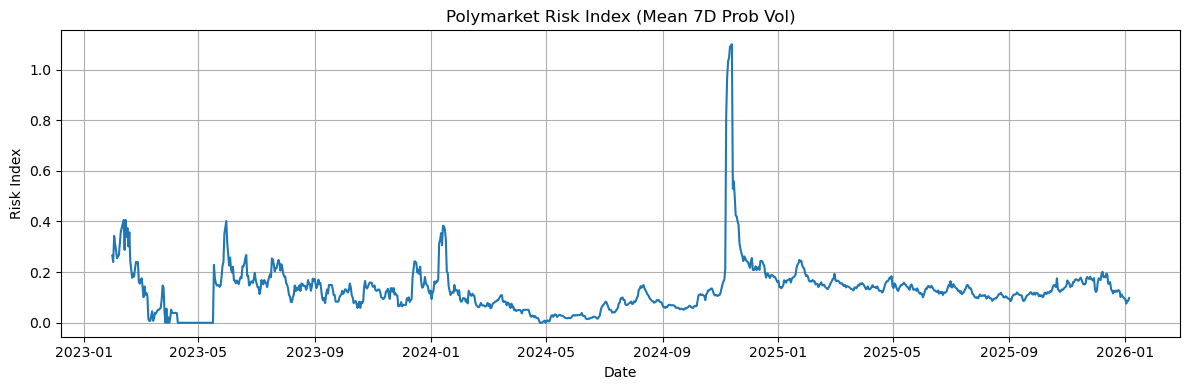

In [60]:
plt.figure(figsize=(12,4))
plt.plot(daily_pd["date"], daily_pd["risk_index"])
plt.title("Polymarket Risk Index (Mean 7D Prob Vol)")
plt.xlabel("Date")
plt.ylabel("Risk Index")
plt.grid(True)
plt.tight_layout()
plt.show()

In [61]:
#huge spike found, identify what event is it
#suspect this is US election given the timing
spike_start = pd.to_datetime("2024-10-01").date()
spike_end = pd.to_datetime("2025-01-31").date()

# 2. Filter using the correct dataframe (df_daily_filtered) 
# and the correct column (risk_index_component)
spike_period = df_daily_filtered.filter(
    (pl.col("date") >= spike_start) & 
    (pl.col("date") <= spike_end)
)

# 3. Aggregate with null-handling
culprits = (
    spike_period
    .group_by("market_id")
    .agg([
        # Use .mean() which ignores nulls by default in Polars
        pl.col("risk_index_component").mean().alias("avg_vol_in_spike"),
        pl.col("risk_index_component").max().alias("peak_vol_in_spike"),
        pl.col("daily_updates").sum().alias("total_activity")
    ])
    # Join with market questions to see what they are
    .join(df_markets.select(["market_id", "question"]), on="market_id")
    # Filter out markets that are still null (e.g., less than 7 days of data)
    .filter(pl.col("avg_vol_in_spike").is_not_null())
    .sort("avg_vol_in_spike", descending=True)
)

print(f"Top Volatility Contributors found: {len(culprits)}")
print(culprits.head(15))

Top Volatility Contributors found: 2055
shape: (15, 5)
┌───────────┬──────────────────┬───────────────────┬────────────────┬──────────────────────────────┐
│ market_id ┆ avg_vol_in_spike ┆ peak_vol_in_spike ┆ total_activity ┆ question                     │
│ ---       ┆ ---              ┆ ---               ┆ ---            ┆ ---                          │
│ str       ┆ f64              ┆ f64               ┆ u32            ┆ str                          │
╞═══════════╪══════════════════╪═══════════════════╪════════════════╪══════════════════════════════╡
│ 512308    ┆ 2.815109         ┆ 2.815109          ┆ 8              ┆ Will Trump nominate Ben      │
│           ┆                  ┆                   ┆                ┆ Carson…                      │
│ 512363    ┆ 2.702854         ┆ 2.70607           ┆ 9              ┆ Will Trump tweet 15-19 times │
│           ┆                  ┆                   ┆                ┆ N…                           │
│ 512264    ┆ 2.586958         ┆ 2.5

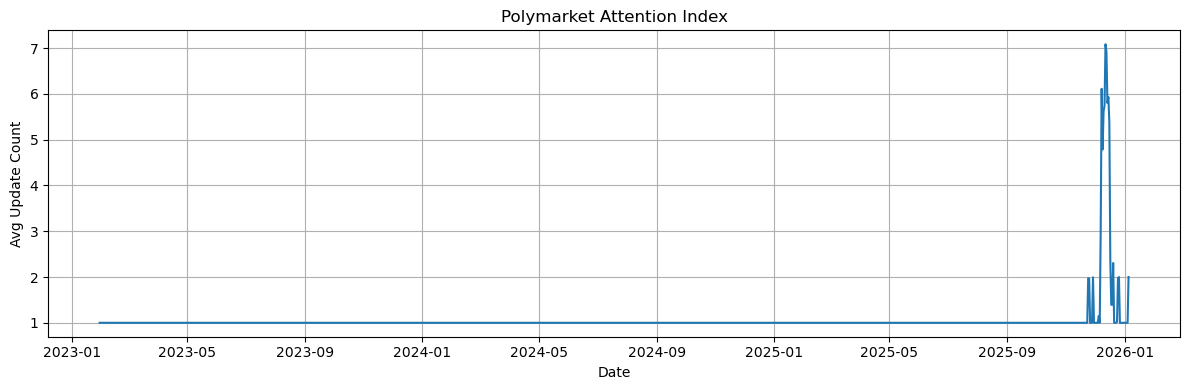

In [62]:
plt.figure(figsize=(12,4))
plt.plot(daily_pd["date"], daily_pd["attention_index"])
plt.title("Polymarket Attention Index")
plt.xlabel("Date")
plt.ylabel("Avg Update Count")
plt.grid(True)
plt.tight_layout()
plt.show()

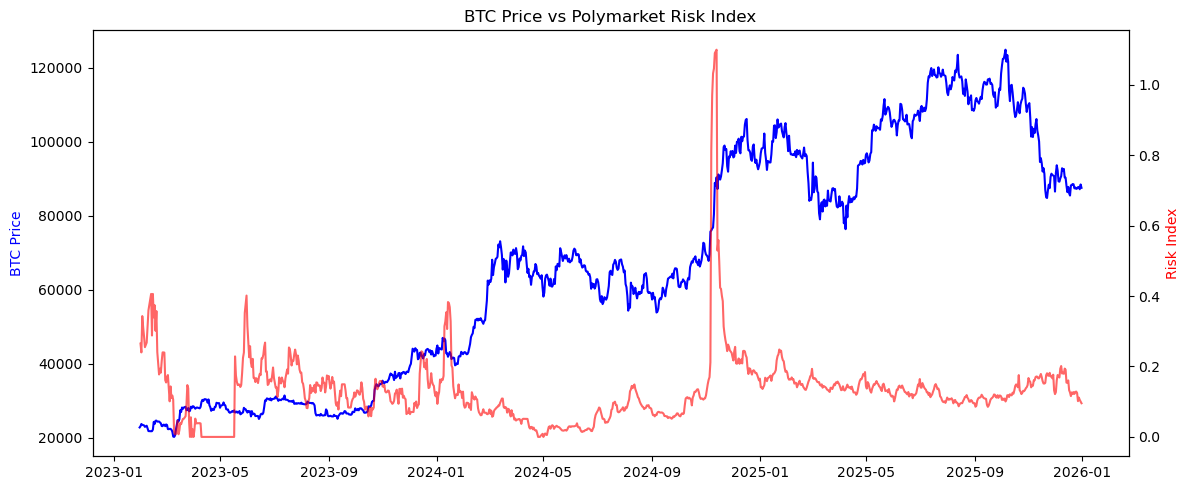

In [63]:
# merge odd history with btc to see BTC price movement with odd volatility move
btc_pd = df.reset_index()[["time", "PriceUSD"]]
daily_pd["date"] = pd.to_datetime(daily_pd["date"]).dt.normalize()
btc_pd["time"] = pd.to_datetime(btc_pd["time"]).dt.normalize()

merged = daily_pd.merge(
    btc_pd,
    left_on="date",
    right_on="time",
    how="inner"
)

fig, ax1 = plt.subplots(figsize=(12,5))

ax1.plot(merged["date"], merged["PriceUSD"], color="blue")
ax1.set_ylabel("BTC Price", color="blue")

ax2 = ax1.twinx()
ax2.plot(merged["date"], merged["risk_index"], color="red", alpha=0.6)
ax2.set_ylabel("Risk Index", color="red")

plt.title("BTC Price vs Polymarket Risk Index")
plt.tight_layout()
plt.show()

# Signal 4
Uses the Polymarket Risk Index to determine if we are in a "Bull" or "Bear" environment and scales the MVRV conviction accordingly.


C:\Users\quant\AppData\Local\Temp\ipykernel_8316\2381867326.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_table = merged.groupby("risk_q5").agg(


         avg_btc_price
risk_q5               
1         53194.529790
2         68286.209257
3         78986.963678
4         71445.694593
5         64320.830316


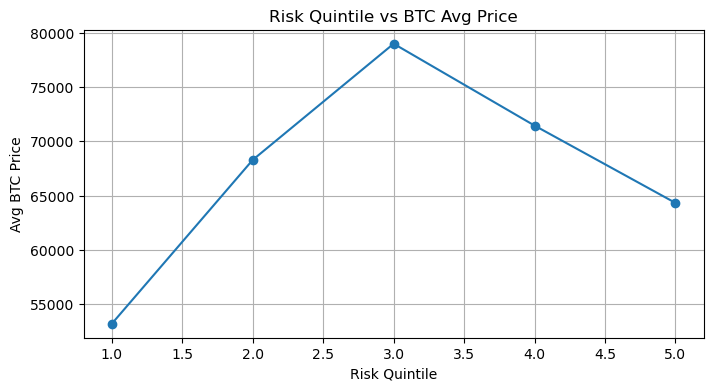

In [64]:
#risk quintile vs BTC $
merged["risk_q5"] = pd.qcut(merged["risk_index"], 5, labels=[1,2,3,4,5])

risk_table = merged.groupby("risk_q5").agg(
    avg_btc_price=("PriceUSD","mean")
)

print(risk_table)

plt.figure(figsize=(8,4))
plt.plot(risk_table.index, risk_table["avg_btc_price"], marker="o")
plt.title("Risk Quintile vs BTC Avg Price")
plt.xlabel("Risk Quintile")
plt.ylabel("Avg BTC Price")
plt.grid(True)
plt.savefig("plots/Risk_Quintile_vs_BTC_Avg_Price.png",
            dpi=300, bbox_inches="tight")
plt.show()

In [65]:
# 1. Calculate Forward Returns (7-day ahead)
# We use log returns for better statistical properties
merged = merged.sort_values('date')
merged['fwd_7d_ret'] = merged['PriceUSD'].shift(-7) / merged['PriceUSD'] - 1

# 2. Advanced Aggregation
risk_regime_stats = merged.groupby('risk_q5', observed=True).agg(
    count=('date', 'count'),
    avg_fwd_ret=('fwd_7d_ret', 'mean'),
    median_fwd_ret=('fwd_7d_ret', 'median'),
    std_fwd_ret=('fwd_7d_ret', 'std'),
    # Hit Rate: % of time the 7-day return was positive
    hit_rate=('fwd_7d_ret', lambda x: (x > 0).mean())
).reset_index()

# 3. Add 'Expectancy' (Risk-Adjusted Return)
risk_regime_stats['expectancy'] = risk_regime_stats['avg_fwd_ret'] / risk_regime_stats['std_fwd_ret']

print("--- Signal 4: Risk Regime Performance ---")
print(risk_regime_stats)

--- Signal 4: Risk Regime Performance ---
  risk_q5  count  avg_fwd_ret  median_fwd_ret  std_fwd_ret  hit_rate  \
0       1    211     0.015662        0.000464     0.074485  0.507109   
1       2    211     0.019157        0.009087     0.078130  0.559242   
2       3    210     0.015404        0.012766     0.052072  0.609524   
3       4    211     0.000588        0.000292     0.053887  0.507109   
4       5    211     0.004158       -0.005072     0.064121  0.450237   

   expectancy  
0    0.210275  
1    0.245196  
2    0.295822  
3    0.010915  
4    0.064840  


C:\Users\quant\AppData\Local\Temp\ipykernel_8316\557666849.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=risk_regime_stats, x='risk_q5', y='avg_fwd_ret', palette='RdYlGn', ax=ax1)
C:\Users\quant\AppData\Local\Temp\ipykernel_8316\557666849.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=merged, x='risk_q5', y='fwd_7d_ret', palette='RdYlGn', ax=ax2)


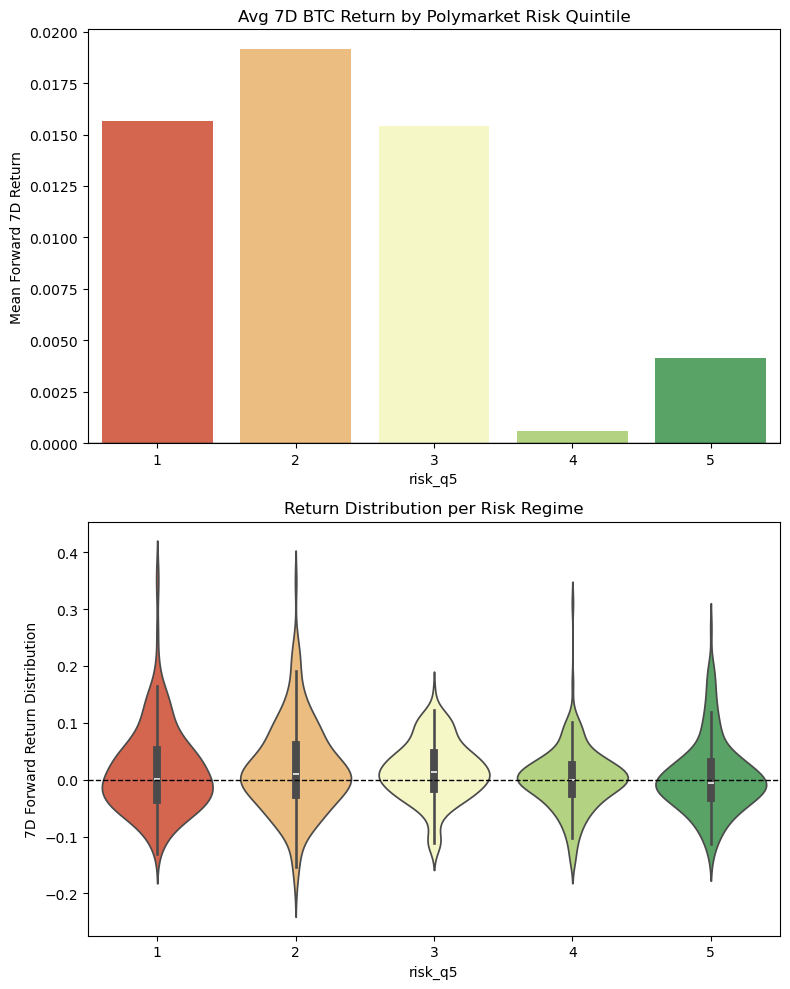

In [66]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 10))

# Plot A: Mean Forward Returns
sns.barplot(data=risk_regime_stats, x='risk_q5', y='avg_fwd_ret', palette='RdYlGn', ax=ax1)
ax1.set_title("Avg 7D BTC Return by Polymarket Risk Quintile")
ax1.set_ylabel("Mean Forward 7D Return")
ax1.axhline(0, color='black', lw=1)

# Plot B: The Distribution of Outcomes (The "Violin" of Risk)
# This shows if high-risk regimes lead to wider tails (crashes or moons)
sns.violinplot(data=merged, x='risk_q5', y='fwd_7d_ret', palette='RdYlGn', ax=ax2)
ax2.set_title("Return Distribution per Risk Regime")
ax2.set_ylabel("7D Forward Return Distribution")
ax2.axhline(0, color='black', lw=1, linestyle='--')

plt.tight_layout()
plt.show()

# 3.5 Trades

In [67]:
trades_df.head()

trade_id,market_id,token_id,timestamp,price,size,side,maker_address,taker_address
str,str,str,datetime[μs],f64,f64,str,str,str
"""0x036e539d9361b15d9ebee9bbd1ae…","""570360""","""214897725164100385865567443423…",2025-11-19 13:44:05,0.977,281.054246,"""BUY""","""0x27d76669db4321111b08fcc7e1a5…","""0xc5d563a36ae78145c45a50134d48…"
"""0x8685bb4a3134f9f664ed7e619b8e…","""570360""","""214897725164100385865567443423…",2025-11-19 13:44:17,0.977,28.0,"""BUY""","""0x33dcee9b336230ed7460c98bec8f…","""0xc5d563a36ae78145c45a50134d48…"
"""0xab71cfe8f3cb18e629b873b65b84…","""570360""","""214897725164100385865567443423…",2025-11-19 13:44:31,0.977,182.0,"""BUY""","""0x87370aa54b8f70fa1c9637f367aa…","""0xc5d563a36ae78145c45a50134d48…"
"""0xfe619b29a0b6aa958cbd565c18f0…","""570360""","""214897725164100385865567443423…",2025-11-19 13:44:49,0.977081,49.0,"""BUY""","""0xa3ad70cf48a2f2b44163e798223c…","""0xc5d563a36ae78145c45a50134d48…"
"""0x953032bcaecd5bf0007c44acddb0…","""570360""","""214897725164100385865567443423…",2025-11-19 13:45:25,0.978,147.8,"""BUY""","""0x4ee06f42e20ee128db78d4225217…","""0xc5d563a36ae78145c45a50134d48…"


In [68]:
# Identify the top 15 traders by total volume (USD)
TopTraders = (
    trades_df
    .with_columns((pl.col("price") * pl.col("size")).alias("usd_value"))
    .group_by("taker_address")
    .agg(pl.col("usd_value").sum().alias("total_spent"))
    .sort("total_spent", descending=True)
    .head(15)
)

print("Top TopTraders on Polymarket:")
print(TopTraders)

Top TopTraders on Polymarket:
shape: (15, 2)
┌─────────────────────────────────┬─────────────┐
│ taker_address                   ┆ total_spent │
│ ---                             ┆ ---         │
│ str                             ┆ f64         │
╞═════════════════════════════════╪═════════════╡
│ 0xc5d563a36ae78145c45a50134d48… ┆ 6.7263e8    │
│ 0x4bfb41d5b3570defd03c39a9a4d8… ┆ 4.9879e8    │
│                                 ┆ 1.5007e8    │
│ 0xd218e474776403a330142299f779… ┆ 2.1735e7    │
│ 0x0540f430df85c770e0a4fb79d849… ┆ 1.3320e7    │
│ …                               ┆ …           │
│ 0x9155e8cf81a3fb557639d23d43f1… ┆ 4.7473e6    │
│ 0x8e9eedf20dfa70956d49f608a205… ┆ 4.1986e6    │
│ 0x63d43bbb87f85af03b8f2f9e2fad… ┆ 4.0525e6    │
│ 0x24c8cf69a0e0a17eee21f69d2975… ┆ 4.0287e6    │
│ 0xe34fa89ce3a484cb9543a6f11613… ┆ 4.0251e6    │
└─────────────────────────────────┴─────────────┘


In [69]:
# Identify concentrated bets - certain address responsible for most volume of bets
address_concentration = (
    trades_df
    .group_by("taker_address")
    .agg(pl.count().alias("trade_count"))
    .sort("trade_count", descending=True)
)


C:\Users\quant\AppData\Local\Temp\ipykernel_8316\1888573454.py:5: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  .agg(pl.count().alias("trade_count"))


In [70]:
address_concentration.head(20)

taker_address,trade_count
str,u32
"""0x4bfb41d5b3570defd03c39a9a4d8…",8097122
"""0xc5d563a36ae78145c45a50134d48…",2337895
"""""",1800991
"""0xca85f4b9e472b542e1df039594ee…",929753
"""0x537494c54dee9162534675712f2e…",266541
…,…
"""0x5248313731287b61d714ab9df655…",119335
"""0x21504551452f4c4b67a1fbee6ba7…",105636
"""0x7485d661b858b117a66e1b4fcbec…",104553


In [71]:
#Find big trades
bigtrade_threshold = 100000  # $100k+ single trade

big_bets = (
    trades_df
    .select(["market_id", "timestamp", "price", "size", "side"])
    .with_columns((pl.col("price") * pl.col("size")).alias("usd_value"))
    .filter(pl.col("usd_value") > bigtrade_threshold)
)
big_bets.head(20)


market_id,timestamp,price,size,side,usd_value
str,datetime[μs],f64,f64,str,f64
"""570360""",2025-11-20 15:11:13,0.986,125548.0,"""BUY""",123790.328
"""570360""",2025-11-24 00:46:51,0.982,123210.14,"""BUY""",120992.35748
"""570360""",2025-11-25 07:07:51,0.985,101525.279133,"""BUY""",100002.399946
"""570360""",2025-11-25 17:04:21,0.992,170104.19,"""BUY""",168743.35648
"""570360""",2025-11-25 18:33:09,0.992,195433.07,"""BUY""",193869.60544
…,…,…,…,…,…
"""570363""",2025-11-22 14:39:17,0.996,150000.0,"""BUY""",149400.0
"""570363""",2025-11-22 18:40:25,0.996,169500.0,"""BUY""",168822.0
"""570363""",2025-11-23 18:58:35,0.996,168500.0,"""BUY""",167826.0


In [72]:
big_markets = big_bets.head(20).join(
    df_markets, 
    on="market_id", 
    how="inner"
)
big_markets.sort("usd_value", descending=True).head(10)



market_id,timestamp,price,size,side,usd_value,question,slug,event_slug,category,volume,active,closed,created_at,end_date
str,datetime[μs],f64,f64,str,f64,str,str,str,str,f64,bool,bool,datetime[μs],datetime[μs]
"""570363""",2025-11-09 07:07:15,0.988,827150.0,"""BUY""",817224.2,"""Fed increases interest rates b…","""fed-increases-interest-rates-b…","""fed-decision-in-december""","""""",1.1449e8,true,false,2025-07-31 19:28:09,2025-12-10 00:00:00
"""570360""",2025-11-25 19:01:53,0.992,232763.76,"""BUY""",230901.64992,"""Fed decreases interest rates b…","""fed-decreases-interest-rates-b…","""fed-decision-in-december""","""""",9.8537e7,true,false,2025-07-31 19:28:08,2025-12-10 00:00:00
"""570360""",2025-11-25 18:33:09,0.992,195433.07,"""BUY""",193869.60544,"""Fed decreases interest rates b…","""fed-decreases-interest-rates-b…","""fed-decision-in-december""","""""",9.8537e7,true,false,2025-07-31 19:28:08,2025-12-10 00:00:00
"""570363""",2025-11-18 10:59:49,0.995,171000.0,"""BUY""",170145.0,"""Fed increases interest rates b…","""fed-increases-interest-rates-b…","""fed-decision-in-december""","""""",1.1449e8,true,false,2025-07-31 19:28:09,2025-12-10 00:00:00
"""570363""",2025-11-19 16:02:11,0.995,170900.0,"""BUY""",170045.5,"""Fed increases interest rates b…","""fed-increases-interest-rates-b…","""fed-decision-in-december""","""""",1.1449e8,true,false,2025-07-31 19:28:09,2025-12-10 00:00:00
"""570363""",2025-11-18 12:10:37,0.994,171000.0,"""SELL""",169974.0,"""Fed increases interest rates b…","""fed-increases-interest-rates-b…","""fed-decision-in-december""","""""",1.1449e8,true,false,2025-07-31 19:28:09,2025-12-10 00:00:00
"""570363""",2025-11-19 22:26:17,0.994,170900.0,"""SELL""",169874.6,"""Fed increases interest rates b…","""fed-increases-interest-rates-b…","""fed-decision-in-december""","""""",1.1449e8,true,false,2025-07-31 19:28:09,2025-12-10 00:00:00
"""570363""",2025-11-21 10:50:33,0.996,169500.0,"""BUY""",168822.0,"""Fed increases interest rates b…","""fed-increases-interest-rates-b…","""fed-decision-in-december""","""""",1.1449e8,true,false,2025-07-31 19:28:09,2025-12-10 00:00:00
"""570363""",2025-11-22 18:40:25,0.996,169500.0,"""BUY""",168822.0,"""Fed increases interest rates b…","""fed-increases-interest-rates-b…","""fed-decision-in-december""","""""",1.1449e8,true,false,2025-07-31 19:28:09,2025-12-10 00:00:00



df_whale_flow date range: 2025-04-07 → 2026-01-05
Total days with whale activity: 256


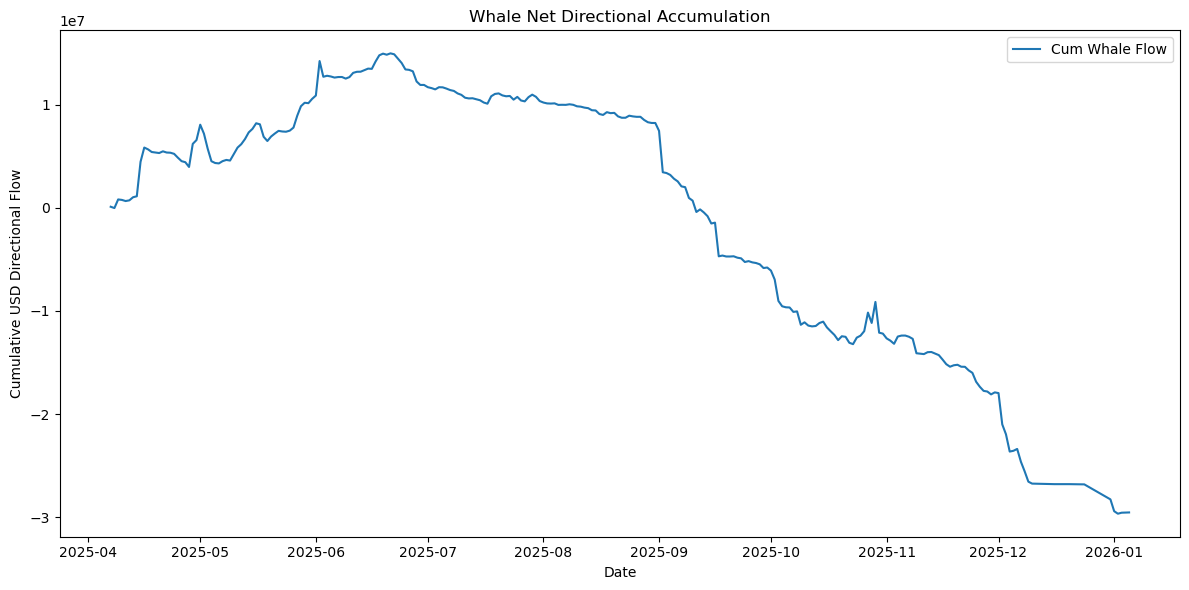

In [73]:
WHALE_THRESHOLD = 10_000
BULL_K = ["yes", "above", "higher", "up", "bull", "win"]
BEAR_K = ["no", "below", "lower", "down", "bear", "lose"]

# fix timestamp corruption 
trades_fixed = trades_df.with_columns(
    (pl.col("timestamp").cast(pl.Int64) // 1000)
    .cast(pl.Datetime("ms"))
    .alias("timestamp")
)


# build directional whale flow
df_whale_flow = (
    trades_fixed
    .filter((pl.col("price") * pl.col("size")) >= WHALE_THRESHOLD)
    .join(df_tokens.select(["token_id", "outcome"]), on="token_id")
    .with_columns([
        pl.col("outcome").str.to_lowercase().alias("outcome_lower"),
        (pl.col("price") * pl.col("size")).alias("notional"),
        pl.col("timestamp").cast(pl.Date).alias("date"),  
    ])
    .with_columns([
        pl.when(pl.col("outcome_lower").str.contains("|".join(BULL_K))).then(pl.lit(1))
          .when(pl.col("outcome_lower").str.contains("|".join(BEAR_K))).then(pl.lit(-1))
          .otherwise(pl.lit(0)).alias("polarity"),
        pl.when(pl.col("side") == "BUY").then(pl.lit(1)).otherwise(pl.lit(-1)).alias("side_sign"),
    ])
    .with_columns(
        (pl.col("side_sign") * pl.col("polarity") * pl.col("notional")).alias("dir_flow")
    )
    .group_by("date")
    .agg(pl.col("dir_flow").sum())
    .sort("date")
    .with_columns(pl.col("dir_flow").cum_sum().alias("cum_whale_flow"))
)

print(f"\ndf_whale_flow date range: {df_whale_flow['date'].min()} → {df_whale_flow['date'].max()}")
print(f"Total days with whale activity: {len(df_whale_flow)}")

# Plot
plt.figure(figsize=(12, 6))
plt.plot(df_whale_flow["date"], df_whale_flow["cum_whale_flow"], label="Cum Whale Flow")
plt.title("Whale Net Directional Accumulation")
plt.xlabel("Date")
plt.ylabel("Cumulative USD Directional Flow")
plt.legend()
plt.tight_layout()
plt.show()

 threshold  trade_count  pct_trades  volume_above  pct_volume
      1000       364610    1.349721  1.460568e+09   62.724689
      5000        60034    0.222235  8.214822e+08   35.278883
     10000        22059    0.081658  5.444218e+08   23.380416
     25000         4996    0.018494  2.867796e+08   12.315865
     50000         1636    0.006056  1.673450e+08    7.186701
    100000          451    0.001670  8.420810e+07    3.616351


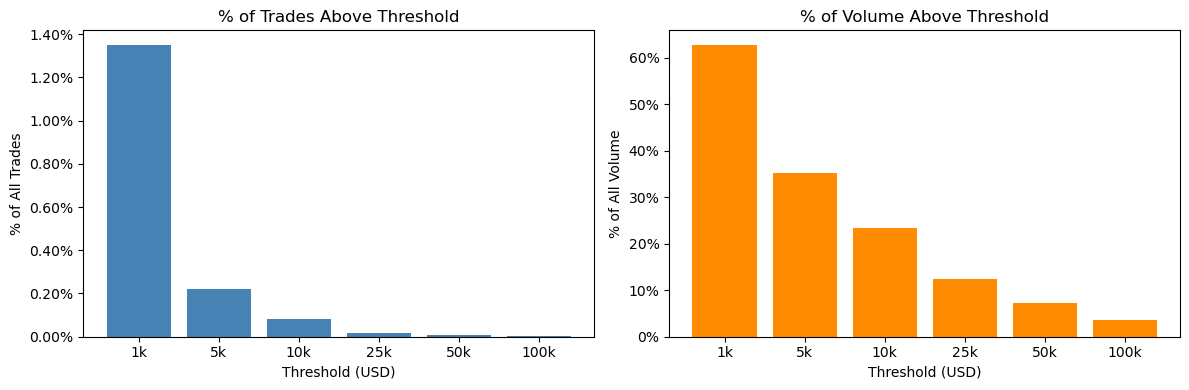

In [74]:
import matplotlib.ticker as mticker
thresholds = [1_000, 5_000, 10_000, 25_000, 50_000, 100_000]
 
trades_with_notional = trades_df.with_columns(
    (pl.col("price") * pl.col("size")).alias("notional")
)
 
total_trades  = len(trades_with_notional)
total_volume  = trades_with_notional["notional"].sum()
 
rows = []
for t in thresholds:
    above = trades_with_notional.filter(pl.col("notional") >= t)
    rows.append({
        "threshold": t,
        "trade_count":  len(above),
        "pct_trades":   100 * len(above) / total_trades,
        "volume_above": above["notional"].sum(),
        "pct_volume":   100 * above["notional"].sum() / total_volume,
    })
 
import pandas as pd
thresh_df = pd.DataFrame(rows)
print(thresh_df.to_string(index=False))
 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
 
axes[0].bar([str(t // 1000) + "k" for t in thresholds], thresh_df["pct_trades"], color="steelblue")
axes[0].set_title("% of Trades Above Threshold")
axes[0].set_xlabel("Threshold (USD)")
axes[0].set_ylabel("% of All Trades")
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter())
 
axes[1].bar([str(t // 1000) + "k" for t in thresholds], thresh_df["pct_volume"], color="darkorange")
axes[1].set_title("% of Volume Above Threshold")
axes[1].set_xlabel("Threshold (USD)")
axes[1].set_ylabel("% of All Volume")
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())
 
plt.tight_layout()
plt.savefig("plots/whale_threshold_sensitivity.png", dpi=300, bbox_inches="tight")
plt.show()

C:\Users\quant\AppData\Local\Temp\ipykernel_8316\295335142.py:24: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  .agg(pl.count().alias("count"))


Polarity distribution among whale trades:
shape: (3, 2)
┌──────────┬───────┐
│ polarity ┆ count │
│ ---      ┆ ---   │
│ i32      ┆ u32   │
╞══════════╪═══════╡
│ -1       ┆ 12957 │
│ 0        ┆ 14    │
│ 1        ┆ 9088  │
└──────────┴───────┘


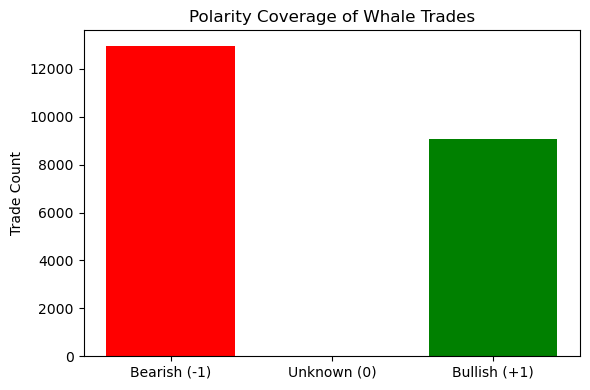

In [75]:
#10000 is a good threshold
WHALE_THRESHOLD = 10000
BULL_K = ["yes", "above", "higher", "up", "bull", "win"]
BEAR_K = ["no", "below", "lower", "down", "bear", "lose"]
 
whale_raw = (
    trades_df
    .with_columns((pl.col("price") * pl.col("size")).alias("notional"))
    .filter(pl.col("notional") >= WHALE_THRESHOLD)
    .join(df_tokens.select(["token_id", "outcome"]), on="token_id", how="left")
    .with_columns([
        pl.col("outcome").str.to_lowercase().alias("outcome_lower"),
    ])
    .with_columns([
        pl.when(pl.col("outcome_lower").str.contains("|".join(BULL_K))).then(pl.lit(1))
          .when(pl.col("outcome_lower").str.contains("|".join(BEAR_K))).then(pl.lit(-1))
          .otherwise(pl.lit(0)).alias("polarity"),
    ])
)
 
polarity_counts = (
    whale_raw
    .group_by("polarity")
    .agg(pl.count().alias("count"))
    .sort("polarity")
)
print("Polarity distribution among whale trades:")
print(polarity_counts)
 
# Visualise
pol_pd = polarity_counts.to_pandas()
pol_pd["label"] = pol_pd["polarity"].map({1: "Bullish (+1)", 0: "Unknown (0)", -1: "Bearish (-1)"})
 
plt.figure(figsize=(6, 4))
colors = {1: "green", 0: "gray", -1: "red"}
bar_colors = [colors[p] for p in pol_pd["polarity"]]
plt.bar(pol_pd["label"], pol_pd["count"], color=bar_colors)
plt.title("Polarity Coverage of Whale Trades")
plt.ylabel("Trade Count")
plt.tight_layout()
plt.savefig("plots/whale_polarity_coverage.png", dpi=300, bbox_inches="tight")
plt.show()

In [76]:
crypto_markets.head()

market_id,question,slug,event_slug,category,volume,active,closed,created_at,end_date
str,str,str,str,str,f64,bool,bool,datetime[μs],datetime[μs]
"""243183""","""Will $ETH be above $3,000 on A…","""will-eth-be-above-3000-on-apri…","""will-eth-be-above-3000-on-apri…","""Crypto""",974114.26,true,true,2022-04-12 16:51:10,2022-04-20 00:00:00
"""243993""","""Will Bitcoin or Ethereum perfo…","""will-bitcoin-or-ethereum-perfo…","""btc-vs-eth-performance-2022""","""Crypto""",4941.31,true,true,2022-05-01 15:39:16,2022-06-01 00:00:00
"""245033""","""Will $ETH be above $2,000 on M…","""will-eth-be-above-2000-on-may-…","""will-eth-be-above-2000-on-may-…","""Crypto""",801754.44,true,true,2022-05-19 15:55:11,2022-05-27 00:00:00
"""246504""","""[From kain.eth] Will Synthetix…","""will-synthetix-capture-more-si…","""will-synthetix-capture-more-si…","""Crypto""",7105.61,true,true,2022-06-08 17:07:00,2022-09-09 00:00:00
"""246676""","""Will $ETH be above $1,200 on J…","""will-eth-be-above-1200-on-july…","""will-eth-be-above-1200-on-july…","""Crypto""",172953.52,true,true,2022-07-09 21:21:54,2022-07-15 00:00:00


Merged rows: 228  |  date range: 2025-04-07 → 2025-12-01


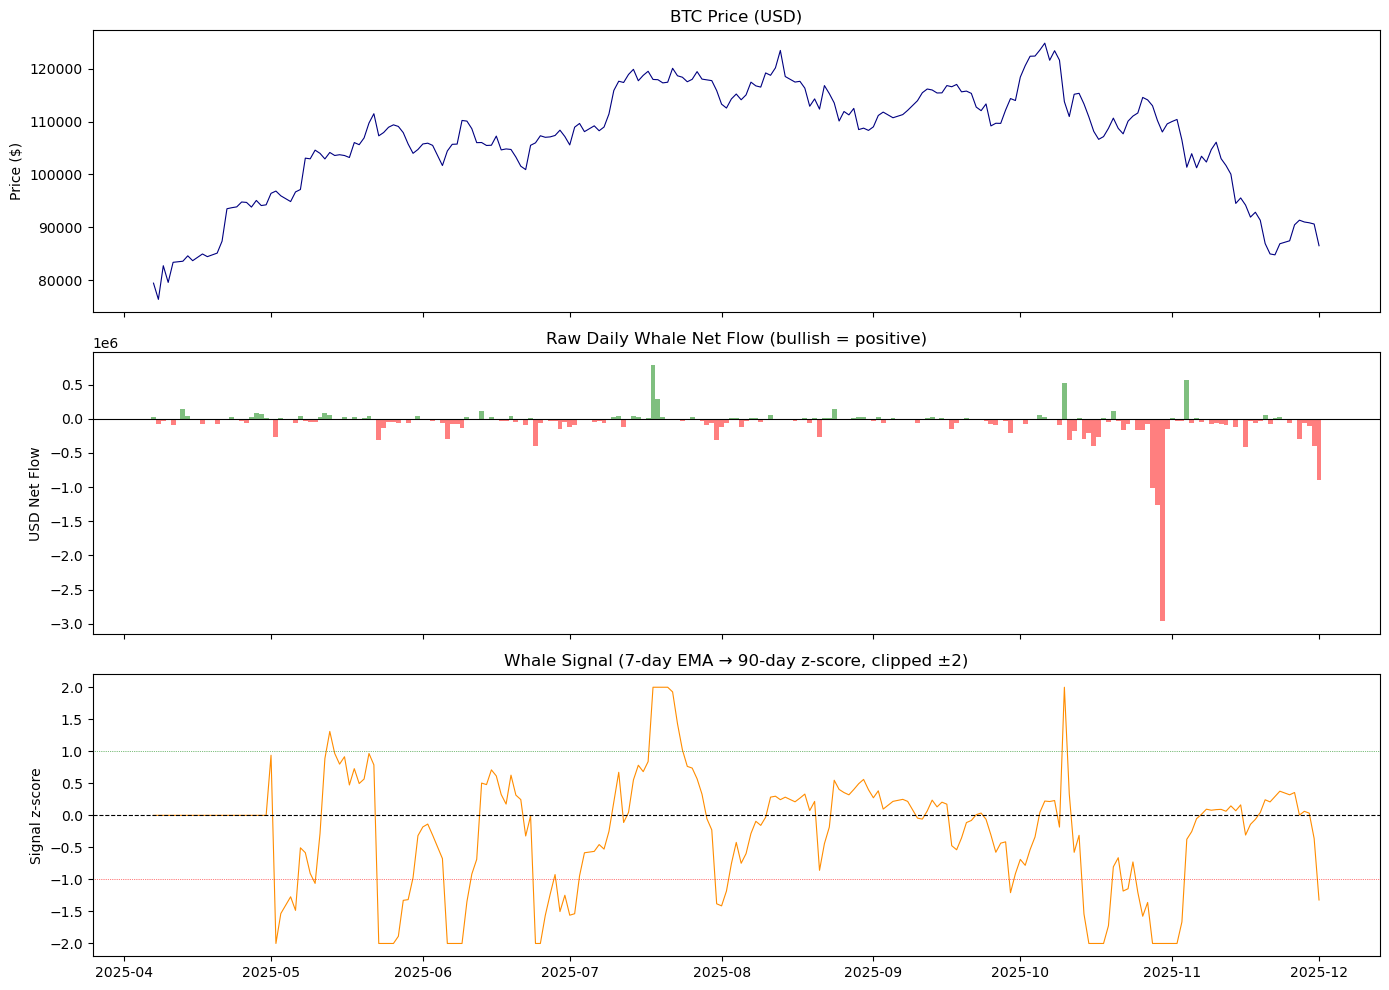

In [77]:
# build daily directional flow ──
whale_daily = (
    trades_df
    .with_columns((pl.col("price") * pl.col("size")).alias("notional"))
    .filter(pl.col("notional") >= WHALE_THRESHOLD)
    .join(
        crypto_markets.select("market_id"),
        on="market_id", how="inner"
    )
    .join(df_tokens.select(["token_id", "outcome"]), on="token_id", how="left")
    .with_columns([
        pl.col("outcome").str.to_lowercase().alias("outcome_lower"),
        # ── FIX: cast to Date (drops time/tz entirely) so dates align with BTC ──
        pl.col("timestamp").cast(pl.Date).alias("date"),
    ])
    .with_columns([
        pl.when(pl.col("outcome_lower").str.contains("|".join(BULL_K))).then(pl.lit(1))
          .when(pl.col("outcome_lower").str.contains("|".join(BEAR_K))).then(pl.lit(-1))
          .otherwise(pl.lit(0)).alias("polarity"),
        pl.when(pl.col("side") == "BUY").then(pl.lit(1)).otherwise(pl.lit(-1)).alias("side_sign"),
    ])
    .with_columns(
        (pl.col("side_sign") * pl.col("polarity") * pl.col("notional")).alias("dir_flow")
    )
    .group_by("date")
    .agg(pl.col("dir_flow").sum().alias("raw_whale_flow"))
    .sort("date")
)

whale_pd = whale_daily.to_pandas()
whale_pd["date"] = pd.to_datetime(whale_pd["date"]).dt.tz_localize(None).dt.normalize()
whale_pd = whale_pd.set_index("date").sort_index()

# smooth with 7-day EMA
whale_pd["whale_ema7"] = whale_pd["raw_whale_flow"].ewm(span=7, adjust=False).mean()

# rolling z-score (90-day window)
def rolling_zscore(series, window=90):
    m = series.rolling(window, min_periods=window // 4).mean()
    s = series.rolling(window, min_periods=window // 4).std()
    return ((series - m) / s).clip(-2, 2).fillna(0)

whale_pd["whale_signal"] = rolling_zscore(whale_pd["whale_ema7"], window=90)

# build BTC side with matching index
btc_pd = eda.reset_index()[["time", "PriceUSD"]].rename(columns={"time": "date"})
# strip tz and normalize so it matches whale_pd's index exactly
btc_pd["date"] = pd.to_datetime(btc_pd["date"]).dt.tz_localize(None).dt.normalize()
btc_pd = btc_pd.set_index("date").sort_index()

# join on index 
merged_whale = whale_pd.join(btc_pd, how="inner")
print(f"Merged rows: {len(merged_whale)}  |  date range: {merged_whale.index.min().date()} → {merged_whale.index.max().date()}")

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(merged_whale.index, merged_whale["PriceUSD"], color="navy", linewidth=0.8)
axes[0].set_title("BTC Price (USD)")
axes[0].set_ylabel("Price ($)")

axes[1].bar(merged_whale.index, merged_whale["raw_whale_flow"],
            color=["green" if v > 0 else "red" for v in merged_whale["raw_whale_flow"]],
            alpha=0.5, width=1)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("Raw Daily Whale Net Flow (bullish = positive)")
axes[1].set_ylabel("USD Net Flow")

axes[2].plot(merged_whale.index, merged_whale["whale_signal"], color="darkorange", linewidth=0.8)
axes[2].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[2].axhline(1,  color="green", linewidth=0.5, linestyle=":")
axes[2].axhline(-1, color="red",   linewidth=0.5, linestyle=":")
axes[2].set_title("Whale Signal (7-day EMA → 90-day z-score, clipped ±2)")
axes[2].set_ylabel("Signal z-score")

plt.tight_layout()
plt.savefig("plots/whale_signal_time_series.png", dpi=300, bbox_inches="tight")
plt.show()

# Signal 3
Big bets on crypto-relevant Polymarket markets act as a "smart money precursor." When large participants (>$10k notional) collectively bet bullish on crypto outcomes, it may signal near-term positive sentiment ahead of BTC price moves.

 lag  correlation
 -14     0.016240
 -13     0.065624
 -12     0.095129
 -11     0.050675
 -10     0.057624
  -9     0.102733
  -8     0.086968
  -7     0.080130
  -6     0.058626
  -5     0.066292
  -4     0.056769
  -3    -0.018306
  -2    -0.017046
  -1    -0.020047
   0     0.005042
   1    -0.010392
   2     0.017807
   3    -0.010003
   4     0.005763
   5    -0.020011
   6     0.017077
   7    -0.050923
   8    -0.010568
   9    -0.016852
  10    -0.025356
  11     0.020837
  12     0.030399
  13     0.026500
  14     0.043863


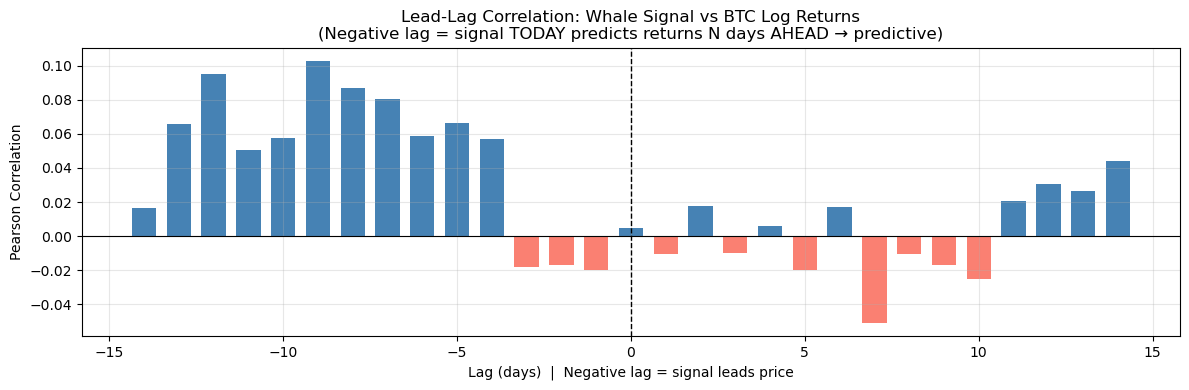

In [78]:
merged_whale["btc_log_ret"] = np.log(merged_whale["PriceUSD"]).diff()
 
lags = range(-14, 15)   # negative = signal leads price; positive = signal lags price
correlations = []
 
for lag in lags:
    # Lag > 0: correlate today's signal with return 'lag' days in the future
    # Lag < 0: correlate today's signal with return 'lag' days in the past
    shifted_ret = merged_whale["btc_log_ret"].shift(-lag)
    corr = merged_whale["whale_signal"].corr(shifted_ret)
    correlations.append({"lag": lag, "correlation": corr})
 
corr_df = pd.DataFrame(correlations)
print(corr_df.to_string(index=False))
 
# Plot
fig, ax = plt.subplots(figsize=(12, 4))
colors = ["steelblue" if c > 0 else "salmon" for c in corr_df["correlation"]]
ax.bar(corr_df["lag"], corr_df["correlation"], color=colors, width=0.7)
ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Lead-Lag Correlation: Whale Signal vs BTC Log Returns\n"
             "(Negative lag = signal TODAY predicts returns N days AHEAD → predictive)")
ax.set_xlabel("Lag (days)  |  Negative lag = signal leads price")
ax.set_ylabel("Pearson Correlation")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("plots/whale_lead_lag_correlation.png", dpi=300, bbox_inches="tight")
plt.show()

=== Whale Signal Quintile → Forward 30D Metrics ===
whale_q5  n  avg_fwd_ret_30d  med_fwd_ret_30d  avg_fwd_vol_30d  prob_dd_lt_20pct
       1 34        -0.034356        -0.017415         0.106437          0.000000
       2 34        -0.035101        -0.024987         0.101332          0.029412
       3 33        -0.018110        -0.011092         0.071045          0.030303
       4 34         0.014746        -0.003927         0.089439          0.000000
       5 34         0.006080        -0.011009         0.065084          0.058824


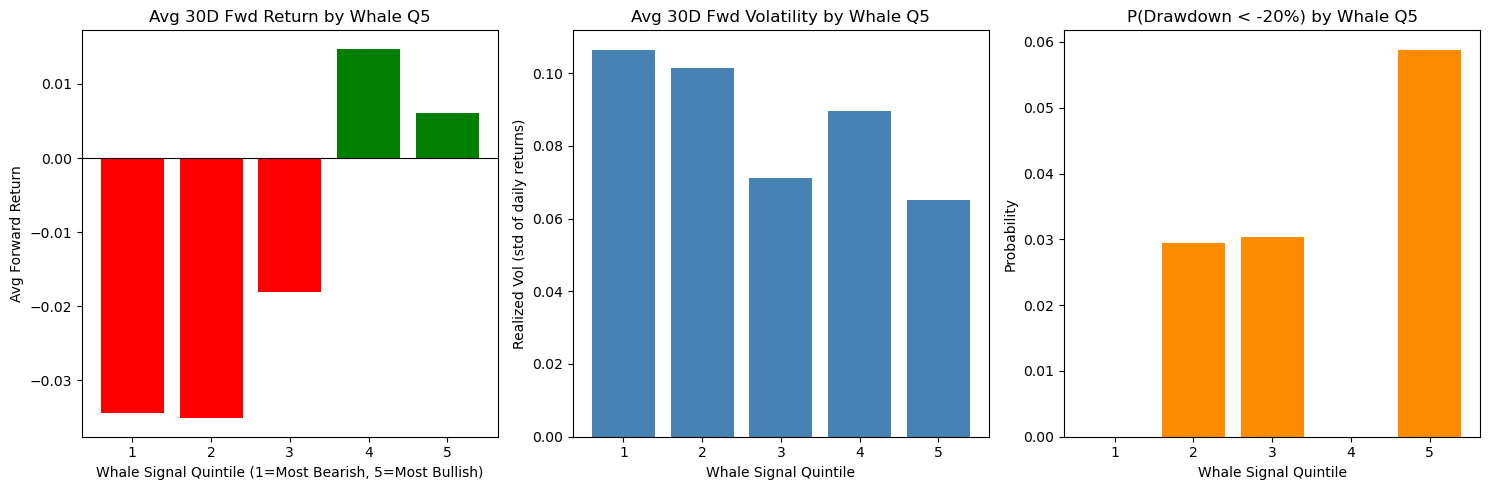

In [79]:
merged_whale = merged_whale.copy()
 
# Forward metrics (30-day horizon, same as MVRV analysis)
h = 30
merged_whale["fwd_ret_30d"]  = merged_whale["PriceUSD"].shift(-h) / merged_whale["PriceUSD"] - 1
future_min = merged_whale["PriceUSD"].shift(-1).rolling(h).min()
merged_whale["fwd_min_dd_30d"] = future_min / merged_whale["PriceUSD"] - 1
 
eda_w = merged_whale.dropna(subset=["whale_signal", "fwd_ret_30d", "fwd_min_dd_30d"]).copy()
 
# Quintile bins
eda_w["whale_q5"] = pd.qcut(eda_w["whale_signal"], 5, labels=[1, 2, 3, 4, 5])
 
whale_table = eda_w.groupby("whale_q5", observed=True).agg(
    n=("PriceUSD", "size"),
    avg_fwd_ret_30d=("fwd_ret_30d", "mean"),
    med_fwd_ret_30d=("fwd_ret_30d", "median"),
    avg_fwd_vol_30d=("fwd_ret_30d", "std"),      # proxy for realized vol
    prob_dd_lt_20pct=("fwd_min_dd_30d", lambda x: (x < -0.20).mean()),
).reset_index()
 
print("=== Whale Signal Quintile → Forward 30D Metrics ===")
print(whale_table.to_string(index=False))
 
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
 
axes[0].bar(whale_table["whale_q5"].astype(str), whale_table["avg_fwd_ret_30d"],
            color=["red" if v < 0 else "green" for v in whale_table["avg_fwd_ret_30d"]])
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_title("Avg 30D Fwd Return by Whale Q5")
axes[0].set_xlabel("Whale Signal Quintile (1=Most Bearish, 5=Most Bullish)")
axes[0].set_ylabel("Avg Forward Return")
 
axes[1].bar(whale_table["whale_q5"].astype(str), whale_table["avg_fwd_vol_30d"], color="steelblue")
axes[1].set_title("Avg 30D Fwd Volatility by Whale Q5")
axes[1].set_xlabel("Whale Signal Quintile")
axes[1].set_ylabel("Realized Vol (std of daily returns)")
 
axes[2].bar(whale_table["whale_q5"].astype(str), whale_table["prob_dd_lt_20pct"], color="darkorange")
axes[2].set_title("P(Drawdown < -20%) by Whale Q5")
axes[2].set_xlabel("Whale Signal Quintile")
axes[2].set_ylabel("Probability")
 
plt.tight_layout()
plt.savefig("plots/whale_quintile_forward_metrics.png", dpi=300, bbox_inches="tight")
plt.show()

Rows after join and dropna: 169
Date range: 2025-05-10 → 2025-10-31

mvrv_q5 counts:
 mvrv_q5
1     0
2     0
3     0
4    86
5    83
Name: count, dtype: int64

whale_q5 counts:
 whale_q5
1    34
2    34
3    33
4    34
5    34
Name: count, dtype: int64

=== 2D Binning: MVRV Q5 (rows) × Whale Q5 (cols) → Avg 30D Return ===
whale_q5      1      2      3      4      5
mvrv_q5                                    
4        -0.095 -0.064 -0.012  0.037  0.053
5         0.021  0.025 -0.027 -0.044 -0.006


C:\Users\quant\AppData\Local\Temp\ipykernel_8316\4029183782.py:44: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot = pivot.applymap(lambda v: f"{v:.1%}") + "\n" + count_pivot.applymap(lambda n: f"n={int(n)}")


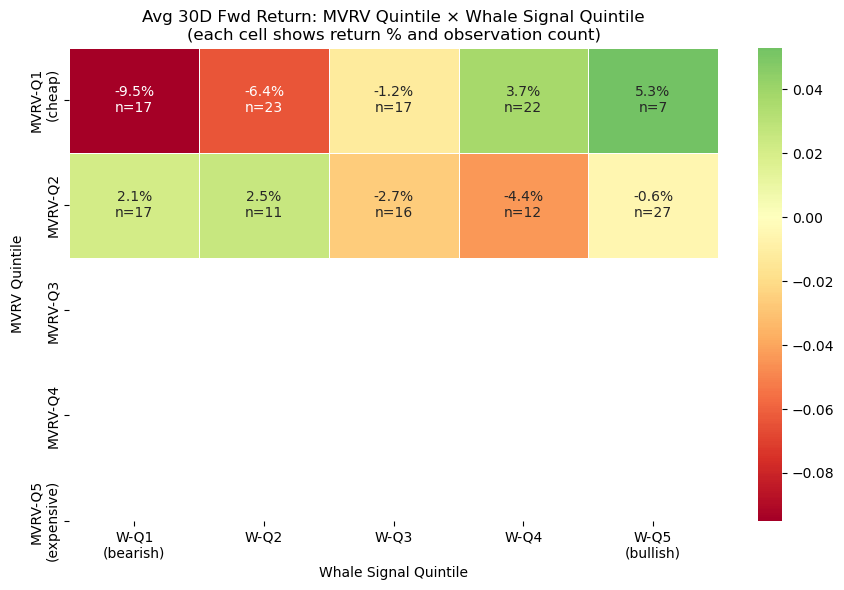

In [80]:
#Whale adds a good second layer signal in the 2D binning with MVRV Quintile
base = eda[["PriceUSD", "CapMVRVCur"]].copy()
base.index = pd.to_datetime(base.index).tz_localize(None).normalize()

# Forward 30-day return (same definition as Section 2)
h = 30
base["fwd_ret_30d"] = base["PriceUSD"].shift(-h) / base["PriceUSD"] - 1

# MVRV quintile — recompute here so we always have all 5 bins
base["mvrv_q5"] = pd.qcut(base["CapMVRVCur"], 5, labels=[1, 2, 3, 4, 5])

# ── 2. Bring in whale_signal from eda_w (built in 84-C / 84-E) ───────────────
# eda_w already has whale_signal and whale_q5 as a DatetimeIndex
whale_side = eda_w[["whale_signal", "whale_q5"]].copy()
whale_side.index = pd.to_datetime(whale_side.index).tz_localize(None).normalize()

# ── 3. Join on index (both now tz-naive, normalized) ─────────────────────────
combined = base.join(whale_side, how="inner")
combined = combined.dropna(subset=["mvrv_q5", "whale_q5", "fwd_ret_30d"])

print(f"Rows after join and dropna: {len(combined)}")
print(f"Date range: {combined.index.min().date()} → {combined.index.max().date()}")
print("\nmvrv_q5 counts:\n", combined["mvrv_q5"].value_counts().sort_index())
print("\nwhale_q5 counts:\n", combined["whale_q5"].value_counts().sort_index())

# ── 4. Pivot and plot ─────────────────────────────────────────────────────────
pivot = (
    combined
    .groupby(["mvrv_q5", "whale_q5"], observed=True)["fwd_ret_30d"]
    .mean()
    .unstack("whale_q5")
)

print("\n=== 2D Binning: MVRV Q5 (rows) × Whale Q5 (cols) → Avg 30D Return ===")
print(pivot.round(3))

# Build annotation labels (show % and count)
count_pivot = (
    combined
    .groupby(["mvrv_q5", "whale_q5"], observed=True)["fwd_ret_30d"]
    .count()
    .unstack("whale_q5")
)
annot = pivot.applymap(lambda v: f"{v:.1%}") + "\n" + count_pivot.applymap(lambda n: f"n={int(n)}")

plt.figure(figsize=(9, 6))
sns.heatmap(
    pivot,
    annot=annot,
    fmt="",
    cmap="RdYlGn",
    center=0,
    linewidths=0.5,
    xticklabels=["W-Q1\n(bearish)", "W-Q2", "W-Q3", "W-Q4", "W-Q5\n(bullish)"],
    yticklabels=["MVRV-Q1\n(cheap)", "MVRV-Q2", "MVRV-Q3", "MVRV-Q4", "MVRV-Q5\n(expensive)"],
)
plt.title("Avg 30D Fwd Return: MVRV Quintile × Whale Signal Quintile\n"
          "(each cell shows return % and observation count)")
plt.xlabel("Whale Signal Quintile")
plt.ylabel("MVRV Quintile")
plt.tight_layout()
plt.savefig("plots/whale_mvrv_2d_binning.png", dpi=300, bbox_inches="tight")
plt.show()

# What to look for:
# • MVRV-Q1 + W-Q5 (top-left to bottom-right diagonal extreme) = highest return?
#   → whale signal adds a second dimension on top of MVRV alone.
# • Does the colour get greener as whale quintile increases within each MVRV row?
#   → directional value within each valuation regime.
# • Small n values mean the cell is unreliable — check count annotations.

Markets with Highest Whale Dominance (top 20):
shape: (20, 5)
┌─────────────────────────────────┬──────────┬─────────────────┬───────────────┬────────────────┐
│ question                        ┆ category ┆ whale_dominance ┆ total_vol     ┆ unique_traders │
│ ---                             ┆ ---      ┆ ---             ┆ ---           ┆ ---            │
│ str                             ┆ str      ┆ f64             ┆ f64           ┆ u32            │
╞═════════════════════════════════╪══════════╪═════════════════╪═══════════════╪════════════════╡
│ Will Karoline Leavitt say "Sex… ┆          ┆ 0.999761        ┆ 64875.639138  ┆ 6              │
│ Will the price of Solana be be… ┆          ┆ 0.994442        ┆ 50229.163037  ┆ 8              │
│ Will the price of Ethereum be … ┆          ┆ 0.993953        ┆ 2.2897e6      ┆ 49             │
│ Will Trump's approval rating b… ┆          ┆ 0.981102        ┆ 93711.172022  ┆ 85             │
│ Will Trump say "Tom" or "Homan… ┆          ┆ 0.977286 

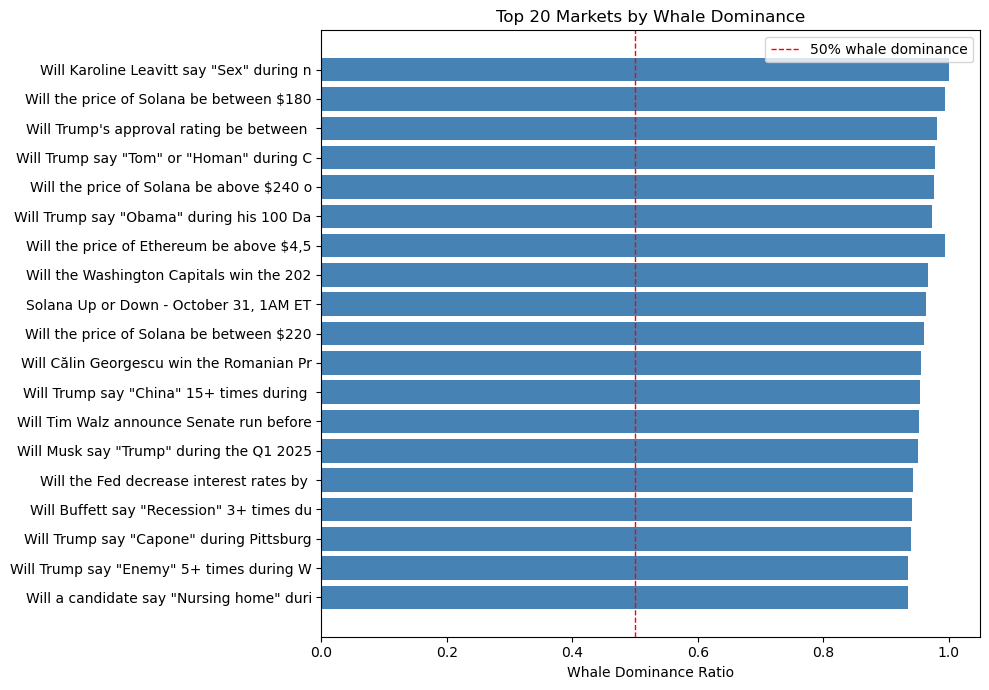

In [81]:
whale_stats = (
    trades_df
    .with_columns((pl.col("price") * pl.col("size")).alias("usd_value"))
    .group_by("market_id")
    .agg([
        pl.col("usd_value").sum().alias("total_vol"),
        pl.col("usd_value").filter(pl.col("usd_value") >= WHALE_THRESHOLD).sum().alias("whale_vol"),
        pl.col("taker_address").n_unique().alias("unique_traders"),
    ])
    .with_columns(
        (pl.col("whale_vol") / pl.col("total_vol")).alias("whale_dominance")
    )
    .filter(pl.col("total_vol") > 50_000)   # only markets with meaningful volume
)
 
whale_report = (
    whale_stats
    .join(df_markets.select(["market_id", "question", "category"]), on="market_id", how="left")
    .sort("whale_dominance", descending=True)
    .head(20)
)
 
print("Markets with Highest Whale Dominance (top 20):")
print(whale_report.select(["question", "category", "whale_dominance", "total_vol", "unique_traders"]))
 
import pandas as pd
import matplotlib.pyplot as plt
 
wd_pd = whale_report.to_pandas()
wd_pd["short_q"] = wd_pd["question"].str[:40]
 
plt.figure(figsize=(10, 7))
plt.barh(wd_pd["short_q"][::-1], wd_pd["whale_dominance"][::-1], color="steelblue")
plt.axvline(0.5, color="red", linestyle="--", linewidth=1, label="50% whale dominance")
plt.xlabel("Whale Dominance Ratio")
plt.title("Top 20 Markets by Whale Dominance")
plt.legend()
plt.tight_layout()
plt.savefig("plots/whale_dominance_markets.png", dpi=300, bbox_inches="tight")
plt.show()